In [1]:
# CryptoGuard
# AI-Based Blockchain Transaction Risk and Anomaly Detection System
#
# Notebook: 01 - Data Understanding
# Purpose: Explore and understand the Elliptic++ Bitcoin transaction dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the transaction features
features = pd.read_csv("../Data/raw/txs_features.txt")

# Load the transaction labels
classes = pd.read_csv("../Data/raw/txs_classes.txt")

# Load the transaction relationships
edges = pd.read_csv("../Data/raw/txs_edgelist.txt")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
print("FEATURES")
print("Rows:", features.shape[0])
print("Columns:", features.shape[1])

print("\nCLASSES")
print("Rows:", classes.shape[0])
print("Columns:", classes.shape[1])

print("\nEDGES")
print("Rows:", edges.shape[0])
print("Columns:", edges.shape[1])

FEATURES
Rows: 203769
Columns: 184

CLASSES
Rows: 203769
Columns: 2

EDGES
Rows: 234355
Columns: 2


In [5]:
 # Check missing values in each dataset

print("=== FEATURES: Missing Values ===")
print("Total missing values:", features.isnull().sum().sum())

print("\n=== CLASSES: Missing Values ===")
print("Total missing values:", classes.isnull().sum().sum())

print("\n=== EDGES: Missing Values ===")
print("Total missing values:", edges.isnull().sum().sum())

=== FEATURES: Missing Values ===
Total missing values: 16405

=== CLASSES: Missing Values ===
Total missing values: 0

=== EDGES: Missing Values ===
Total missing values: 0


In [6]:
# Identify columns containing missing values

missing_features = features.isnull().sum()

missing_features = missing_features[missing_features > 0].sort_values(
    ascending=False
)

print("Columns containing missing values:")
print(missing_features)

print("\nNumber of columns affected:", len(missing_features))

Columns containing missing values:
in_txs_degree           965
out_txs_degree          965
total_BTC               965
fees                    965
size                    965
num_input_addresses     965
num_output_addresses    965
in_BTC_min              965
in_BTC_max              965
in_BTC_mean             965
in_BTC_median           965
in_BTC_total            965
out_BTC_min             965
out_BTC_max             965
out_BTC_mean            965
out_BTC_median          965
out_BTC_total           965
dtype: int64

Number of columns affected: 17


In [7]:
# Percentage of missing values in affected columns

missing_percentage = (
    features.isnull().mean() * 100
)

missing_percentage = missing_percentage[
    missing_percentage > 0
].sort_values(ascending=False)

print(missing_percentage)

in_txs_degree           0.473575
out_txs_degree          0.473575
total_BTC               0.473575
fees                    0.473575
size                    0.473575
num_input_addresses     0.473575
num_output_addresses    0.473575
in_BTC_min              0.473575
in_BTC_max              0.473575
in_BTC_mean             0.473575
in_BTC_median           0.473575
in_BTC_total            0.473575
out_BTC_min             0.473575
out_BTC_max             0.473575
out_BTC_mean            0.473575
out_BTC_median          0.473575
out_BTC_total           0.473575
dtype: float64


In [8]:
# Percentage of missing values in affected columns

missing_percentage = (
    features.isnull().mean() * 100
)

missing_percentage = missing_percentage[
    missing_percentage > 0
].sort_values(ascending=False)

print(missing_percentage)

in_txs_degree           0.473575
out_txs_degree          0.473575
total_BTC               0.473575
fees                    0.473575
size                    0.473575
num_input_addresses     0.473575
num_output_addresses    0.473575
in_BTC_min              0.473575
in_BTC_max              0.473575
in_BTC_mean             0.473575
in_BTC_median           0.473575
in_BTC_total            0.473575
out_BTC_min             0.473575
out_BTC_max             0.473575
out_BTC_mean            0.473575
out_BTC_median          0.473575
out_BTC_total           0.473575
dtype: float64


In [9]:
missing_mask = features[
    [
        "in_txs_degree",
        "out_txs_degree",
        "total_BTC",
        "fees",
        "size",
        "num_input_addresses",
        "num_output_addresses",
        "in_BTC_min",
        "in_BTC_max",
        "in_BTC_mean",
        "in_BTC_median",
        "in_BTC_total",
        "out_BTC_min",
        "out_BTC_max",
        "out_BTC_mean",
        "out_BTC_median",
        "out_BTC_total"
    ]
].isnull()

missing_rows = missing_mask.all(axis=1)

print("Rows missing ALL 17 features:", missing_rows.sum())

Rows missing ALL 17 features: 965


In [10]:
missing_transactions = features[missing_rows]

print(
    missing_transactions["Time step"].value_counts().sort_index()
)

Time step
1      36
2      15
4       4
5       2
7      22
8      26
9       5
11      7
12      8
13     12
14      2
15     16
16     12
17     12
18      7
20      4
21      3
22     16
23     33
24     12
25      7
26      4
27     12
28      1
29      9
30      8
31     41
32     12
33      3
34     50
35     21
36    117
37     62
38     17
39     43
40     23
41     30
42     15
43    144
44     23
45     40
46      7
47     16
49      6
Name: count, dtype: int64


In [11]:
features.fillna(0)

,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_min,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.534072,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,5.611878,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.456608,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,0.308900,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,158304003,49,-0.165622,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156113,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
203765,158303998,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
203766,158303966,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
203767,161526077,49,-0.172212,-0.139573,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.162856,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000


In [12]:
print("Rows missing ALL 17 features:", missing_rows.sum())

print("\nMissing transactions by Time step:")
print(
    missing_transactions["Time step"]
    .value_counts()
    .sort_index()
)

Rows missing ALL 17 features: 965

Missing transactions by Time step:
Time step
1      36
2      15
4       4
5       2
7      22
8      26
9       5
11      7
12      8
13     12
14      2
15     16
16     12
17     12
18      7
20      4
21      3
22     16
23     33
24     12
25      7
26      4
27     12
28      1
29      9
30      8
31     41
32     12
33      3
34     50
35     21
36    117
37     62
38     17
39     43
40     23
41     30
42     15
43    144
44     23
45     40
46      7
47     16
49      6
Name: count, dtype: int64


In [13]:
print("=== DUPLICATE CHECK ===")

print("Duplicate feature rows:", features.duplicated().sum())
print("Duplicate class rows:", classes.duplicated().sum())
print("Duplicate edge rows:", edges.duplicated().sum())

print("\n=== DUPLICATE TRANSACTION IDs ===")

print("Duplicate feature txIds:", features["txId"].duplicated().sum())
print("Duplicate class txIds:", classes["txId"].duplicated().sum())

=== DUPLICATE CHECK ===
Duplicate feature rows: 0
Duplicate class rows: 0
Duplicate edge rows: 0

=== DUPLICATE TRANSACTION IDs ===
Duplicate feature txIds: 0
Duplicate class txIds: 0


In [14]:
print("=== CLASS DISTRIBUTION ===")

class_counts = classes["class"].value_counts().sort_index()

print(class_counts)

print("\nPercentage distribution:")

class_percent = classes["class"].value_counts(normalize=True).sort_index() * 100

print(class_percent.round(2))

=== CLASS DISTRIBUTION ===
class
1      4545
2     42019
3    157205
Name: count, dtype: int64

Percentage distribution:
class
1     2.23
2    20.62
3    77.15
Name: proportion, dtype: float64


In [15]:
print("=== DATA TYPES ===")

print(features.dtypes.value_counts())

print("\n=== NON-NUMERIC COLUMNS ===")

print(features.select_dtypes(exclude="number").columns.tolist())

=== DATA TYPES ===
float64    182
int64        2
Name: count, dtype: int64

=== NON-NUMERIC COLUMNS ===
[]


In [16]:
print("=== IDENTIFIER / TIME COLUMNS ===")

print("Transaction ID:", ["txId"])
print("Time column:", ["Time step"])


print("\n=== LOCAL FEATURES ===")

local_features = [
    col for col in features.columns
    if col.startswith("Local_feature_")
]

print("Number of local features:", len(local_features))
print(local_features[:5], "...", local_features[-5:])


print("\n=== AGGREGATE FEATURES ===")

aggregate_features = [
    col for col in features.columns
    if col.startswith("Aggregate_feature_")
]

print("Number of aggregate features:", len(aggregate_features))
print(aggregate_features[:5], "...", aggregate_features[-5:])


print("\n=== TRANSACTION / NETWORK FEATURES ===")

transaction_features = [
    col for col in features.columns
    if col not in ["txId", "Time step"]
    and not col.startswith("Local_feature_")
    and not col.startswith("Aggregate_feature_")
]

print("Number of transaction/network features:", len(transaction_features))
print(transaction_features)


=== IDENTIFIER / TIME COLUMNS ===
Transaction ID: ['txId']
Time column: ['Time step']

=== LOCAL FEATURES ===
Number of local features: 93
['Local_feature_1', 'Local_feature_2', 'Local_feature_3', 'Local_feature_4', 'Local_feature_5'] ... ['Local_feature_89', 'Local_feature_90', 'Local_feature_91', 'Local_feature_92', 'Local_feature_93']

=== AGGREGATE FEATURES ===
Number of aggregate features: 72
['Aggregate_feature_1', 'Aggregate_feature_2', 'Aggregate_feature_3', 'Aggregate_feature_4', 'Aggregate_feature_5'] ... ['Aggregate_feature_68', 'Aggregate_feature_69', 'Aggregate_feature_70', 'Aggregate_feature_71', 'Aggregate_feature_72']

=== TRANSACTION / NETWORK FEATURES ===
Number of transaction/network features: 17
['in_txs_degree', 'out_txs_degree', 'total_BTC', 'fees', 'size', 'num_input_addresses', 'num_output_addresses', 'in_BTC_min', 'in_BTC_max', 'in_BTC_mean', 'in_BTC_median', 'in_BTC_total', 'out_BTC_min', 'out_BTC_max', 'out_BTC_mean', 'out_BTC_median', 'out_BTC_total']


In [17]:
print("=== TRANSACTION ID CONSISTENCY CHECK ===")

feature_ids = set(features["txId"])
class_ids = set(classes["txId"])

print("Unique transaction IDs in features:", len(feature_ids))
print("Unique transaction IDs in classes:", len(class_ids))

print("\nTransactions in features but not classes:",
      len(feature_ids - class_ids))

print("Transactions in classes but not features:",
      len(class_ids - feature_ids))

=== TRANSACTION ID CONSISTENCY CHECK ===
Unique transaction IDs in features: 203769
Unique transaction IDs in classes: 203769

Transactions in features but not classes: 0
Transactions in classes but not features: 0


In [18]:
print("=== MERGING FEATURES AND CLASS LABELS ===")

data = features.merge(
    classes,
    on="txId",
    how="inner",
    validate="one_to_one"
)

print("Merged dataset shape:", data.shape)

print("\nClass distribution after merge:")
print(data["class"].value_counts().sort_index())

=== MERGING FEATURES AND CLASS LABELS ===
Merged dataset shape: (203769, 185)

Class distribution after merge:
class
1      4545
2     42019
3    157205
Name: count, dtype: int64


In [19]:
print("=== CREATING MODELING DATASETS ===")

# Known/labeled transactions: Class 1 and Class 2
labeled_data = data[data["class"].isin([1, 2])].copy()

# Unknown transactions: Class 3
unknown_data = data[data["class"] == 3].copy()

print("Labeled dataset shape:", labeled_data.shape)
print("Unknown dataset shape:", unknown_data.shape)

print("\nLabeled class distribution:")
print(labeled_data["class"].value_counts().sort_index())

print("\nUnknown transactions:", len(unknown_data))

=== CREATING MODELING DATASETS ===
Labeled dataset shape: (46564, 185)
Unknown dataset shape: (157205, 185)

Labeled class distribution:
class
1     4545
2    42019
Name: count, dtype: int64

Unknown transactions: 157205


=== LABELED DATA CLASS DISTRIBUTION ===
class
1     4545
2    42019
Name: count, dtype: int64


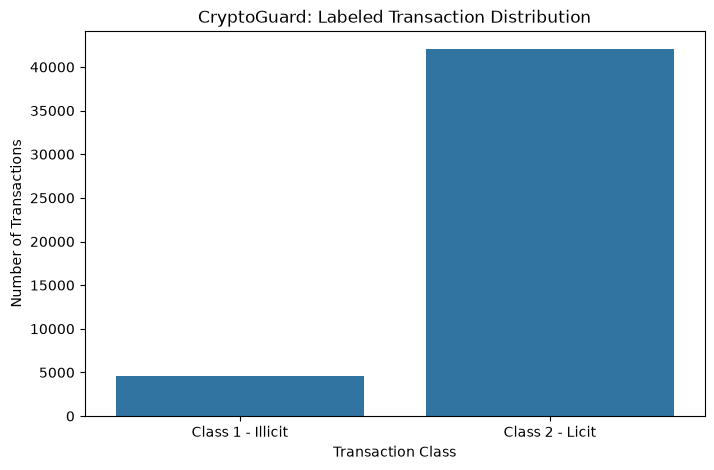

In [20]:
print("=== LABELED DATA CLASS DISTRIBUTION ===")

labeled_counts = labeled_data["class"].value_counts().sort_index()

print(labeled_counts)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=labeled_counts.index.astype(str),
    y=labeled_counts.values
)

plt.title("CryptoGuard: Labeled Transaction Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Class 1 - Illicit", "Class 2 - Licit"]
)

plt.show()

In [21]:
print("=== FEATURE QUALITY CHECK ===")

# Remove ID and label columns for this check
feature_data = labeled_data.drop(columns=["txId", "class"])

# Check infinite values
print("Infinite values:", np.isinf(feature_data).sum().sum())

# Check missing values
print("Missing values:", feature_data.isnull().sum().sum())

# Check columns with missing values
missing_cols = feature_data.columns[feature_data.isnull().any()].tolist()

print("\nColumns with missing values:")
print(missing_cols)

# Check constant columns
constant_cols = [
    col for col in feature_data.columns
    if feature_data[col].nunique(dropna=False) <= 1
]

print("\nConstant columns:", len(constant_cols))
print(constant_cols)

=== FEATURE QUALITY CHECK ===
Infinite values: 0
Missing values: 8823

Columns with missing values:
['in_txs_degree', 'out_txs_degree', 'total_BTC', 'fees', 'size', 'num_input_addresses', 'num_output_addresses', 'in_BTC_min', 'in_BTC_max', 'in_BTC_mean', 'in_BTC_median', 'in_BTC_total', 'out_BTC_min', 'out_BTC_max', 'out_BTC_mean', 'out_BTC_median', 'out_BTC_total']

Constant columns: 0
[]


In [22]:
print("=== MISSING VALUES IN LABELED TRANSACTIONS ===")

missing_mask_labeled = feature_data.isnull().any(axis=1)

print(
    "Labeled transactions with at least one missing value:",
    missing_mask_labeled.sum()
)

print(
    "Labeled transactions with no missing values:",
    (~missing_mask_labeled).sum()
)

print("\nPercentage with missing values:")

print(
    round(missing_mask_labeled.mean() * 100, 2),
    "%"
)


=== MISSING VALUES IN LABELED TRANSACTIONS ===
Labeled transactions with at least one missing value: 519
Labeled transactions with no missing values: 46045

Percentage with missing values:
1.11 %


In [23]:
print("=== TIME STEP DISTRIBUTION ===")

print("Number of unique time steps:",
      labeled_data["Time step"].nunique())

print("\nTime step range:",
      labeled_data["Time step"].min(),
      "to",
      labeled_data["Time step"].max())

print("\nTransactions per time step:")

print(
    labeled_data["Time step"]
    .value_counts()
    .sort_index()
)

=== TIME STEP DISTRIBUTION ===
Number of unique time steps: 49

Time step range: 1 to 49

Transactions per time step:
Time step
1     2147
2     1117
3     1279
4     1440
5     1882
6      485
7     1203
8     1165
9      778
10     972
11     696
12     506
13     809
14     417
15     618
16     530
17     811
18     389
19     745
20     900
21     641
22    1763
23    1187
24    1126
25     594
26     517
27     206
28     284
29    1174
30     524
31     710
32    1323
33     441
34     515
35    1341
36    1708
37     498
38     756
39    1183
40    1211
41    1132
42    2154
43    1370
44    1591
45    1221
46     712
47     846
48     471
49     476
Name: count, dtype: int64


In [24]:
print("=== CLASS DISTRIBUTION BY TIME STEP ===")

time_class_distribution = pd.crosstab(
    labeled_data["Time step"],
    labeled_data["class"]
)

print(time_class_distribution)

=== CLASS DISTRIBUTION BY TIME STEP ===
class        1     2
Time step           
1           17  2130
2           18  1099
3           11  1268
4           30  1410
5            8  1874
6            5   480
7          102  1101
8           67  1098
9          248   530
10          18   954
11         131   565
12          16   490
13         291   518
14          43   374
15         147   471
16         128   402
17          99   712
18          52   337
19          80   665
20         260   640
21         100   541
22         158  1605
23          53  1134
24         137   989
25         118   476
26          96   421
27          24   182
28          85   199
29         329   845
30          83   441
31         106   604
32         342   981
33          23   418
34          37   478
35         182  1159
36          33  1675
37          40   458
38         111   645
39          81  1102
40         112  1099
41         116  1016
42         239  1915
43          24  1346
44          24 

In [25]:
import pandas as pd

# CryptoGuard raw data paths
features_path = r"C:\CryptoGuard\Data\raw\txs_features.txt"
classes_path = r"C:\CryptoGuard\Data\raw\txs_classes.txt"

# Load features and classes
features = pd.read_csv(features_path)
classes = pd.read_csv(classes_path)

print("Features loaded:", features.shape)
print("Classes loaded:", classes.shape)

Features loaded: (203769, 184)
Classes loaded: (203769, 2)


In [92]:
# Merge features and classes

data = features.merge(
    classes,
    on="txId",
    how="inner"
)

# Keep only transactions with known labels
labeled_data = data[
    data["class"].isin([1, 2])
].copy()

print("Merged data:", data.shape)
print("Labeled data:", labeled_data.shape)
print("\nClass distribution:")
print(labeled_data["class"].value_counts().sort_index())

Merged data: (203769, 185)
Labeled data: (46564, 185)

Class distribution:
class
1     4545
2    42019
Name: count, dtype: int64


In [93]:
# Create the chronological train/test split

train_data = labeled_data[
    labeled_data["Time step"] <= 40
].copy()

test_data = labeled_data[
    labeled_data["Time step"] > 40
].copy()

# ML feature columns
feature_columns = [
    col for col in labeled_data.columns
    if col not in ["txId", "Time step", "class"]
]

X_train = train_data[feature_columns].copy()
X_test = test_data[feature_columns].copy()

y_train = train_data["class"].copy()
y_test = test_data["class"].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (36591, 182)
X_test : (9973, 182)
y_train: (36591,)
y_test : (9973,)


In [94]:
from sklearn.impute import SimpleImputer

# Fit imputer ONLY on training data
imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Training missing values after imputation:",
      X_train_imputed.isna().sum().sum())

print("Testing missing values after imputation:",
      X_test_imputed.isna().sum().sum())

Training missing values after imputation: 0
Testing missing values after imputation: 0


In [95]:
import shap

# Create SHAP explainer using the saved XGBoost model
explainer = shap.TreeExplainer(xgb_model)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [96]:
# Create the SHAP sample

X_test_sample = X_test_imputed.sample(
    n=min(2000, len(X_test_imputed)),
    random_state=42
)

print("SHAP sample created successfully!")
print("Sample size:", X_test_sample.shape)

SHAP sample created successfully!
Sample size: (2000, 182)


In [97]:
# Select transaction 12661353 for local SHAP explanation

transaction_id = 12661353

# Find the transaction in the test dataset
transaction_index = X_test.index[
    test_data["txId"] == transaction_id
][0]

transaction = X_test_imputed.loc[[transaction_index]]

print("Transaction selected successfully!")
print("Transaction ID:", transaction_id)
print("Number of features:", transaction.shape[1])

Transaction selected successfully!
Transaction ID: 12661353
Number of features: 182


In [98]:
# Generate SHAP explanation for transaction 12661353

transaction_shap = explainer(transaction)

print("Local SHAP explanation generated successfully!")
print("Transaction:", transaction_id)
print("Number of features:", transaction.shape[1])

Local SHAP explanation generated successfully!
Transaction: 12661353
Number of features: 182


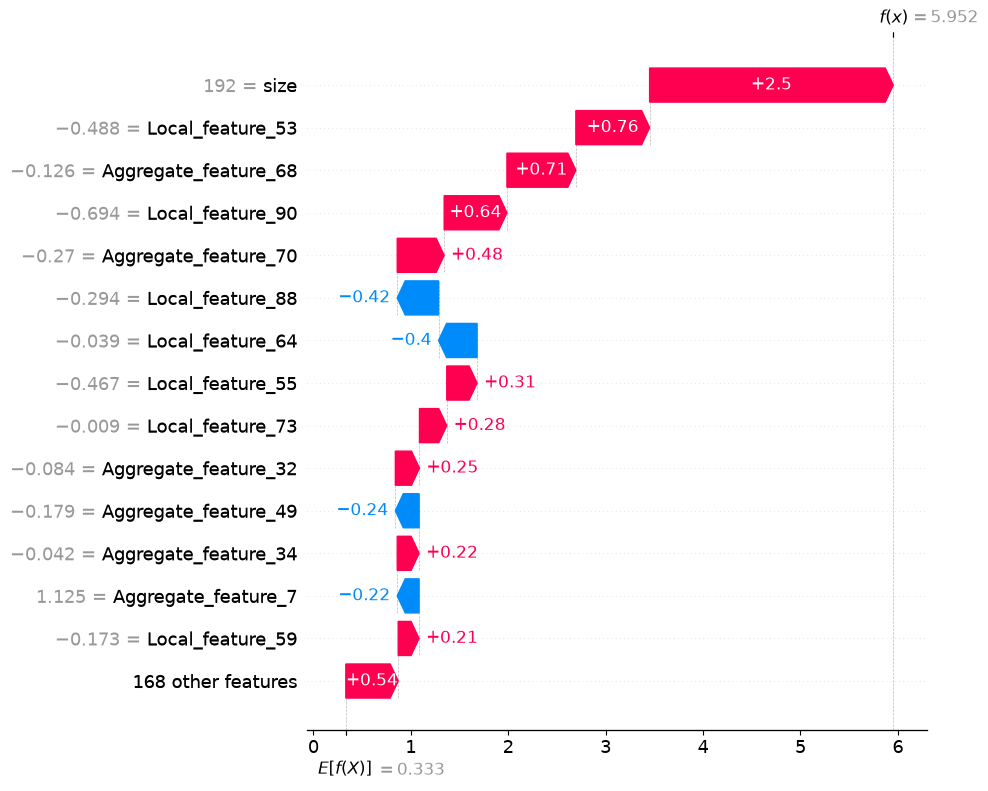

In [99]:
# SHAP waterfall plot for transaction 12661353

shap.plots.waterfall(
    transaction_shap[0],
    max_display=15,
    show=True
)

In [100]:
# Save SHAP explanation for the dashboard

shap_data = pd.DataFrame({
    "feature": transaction.columns,
    "shap_value": transaction_shap.values[0],
    "feature_value": transaction.iloc[0].values
})

shap_path = r"C:\CryptoGuard\Data\processed\shap_transaction_12661353.csv"

shap_data.to_csv(shap_path, index=False)

print("SHAP explanation saved successfully!")
print("Saved to:", shap_path)
print("Rows:", len(shap_data))

SHAP explanation saved successfully!
Saved to: C:\CryptoGuard\Data\processed\shap_transaction_12661353.csv
Rows: 182


In [101]:
# Verify saved SHAP explanation

shap_check = pd.read_csv(
    r"C:\CryptoGuard\Data\processed\shap_transaction_12661353.csv"
)

print("SHAP file loaded successfully!")
print("Shape:", shap_check.shape)

print("\nTop 10 features by absolute SHAP contribution:")
print(
    shap_check
    .assign(abs_shap=shap_check["shap_value"].abs())
    .sort_values("abs_shap", ascending=False)
    [["feature", "shap_value", "feature_value"]]
    .head(10)
)

SHAP file loaded successfully!
Shape: (182, 3)

Top 10 features by absolute SHAP contribution:
                  feature  shap_value  feature_value
169                  size    2.501198     192.000000
52       Local_feature_53    0.757184      -0.488239
160  Aggregate_feature_68    0.707354      -0.125939
89       Local_feature_90    0.644511      -0.694235
162  Aggregate_feature_70    0.481809      -0.269818
87       Local_feature_88   -0.424544      -0.293897
63       Local_feature_64   -0.395217      -0.039146
54       Local_feature_55    0.311347      -0.467437
72       Local_feature_73    0.279920      -0.008718
124  Aggregate_feature_32    0.247766      -0.084100


In [26]:
# ==========================================
# STEP 2: CREATE TRAIN AND TEST DATASETS
# ==========================================

train_data = labeled_data[
    labeled_data["Time step"] <= 40
].copy()

test_data = labeled_data[
    labeled_data["Time step"] > 40
].copy()

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

print("\nTraining time range:")
print(train_data["Time step"].min(), "to", train_data["Time step"].max())

print("\nTesting time range:")
print(test_data["Time step"].min(), "to", test_data["Time step"].max())

print("\nTraining class distribution:")
print(train_data["class"].value_counts().sort_index())

print("\nTesting class distribution:")
print(test_data["class"].value_counts().sort_index())

Training data shape: (36591, 185)
Testing data shape: (9973, 185)

Training time range:
1 to 40

Testing time range:
41 to 49

Training class distribution:
class
1     4021
2    32570
Name: count, dtype: int64

Testing class distribution:
class
1     524
2    9449
Name: count, dtype: int64


In [27]:
# ==========================================
# STEP 3: SEPARATE FEATURES AND TARGET
# ==========================================

# Target variable
y_train = (train_data["class"] == 1).astype(int)
y_test = (test_data["class"] == 1).astype(int)

# Keep transaction IDs separately
train_tx_ids = train_data["txId"].copy()
test_tx_ids = test_data["txId"].copy()

# Create feature datasets
X_train = train_data.drop(
    columns=["txId", "Time step", "class"]
)

X_test = test_data.drop(
    columns=["txId", "Time step", "class"]
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

X_train shape: (36591, 182)
X_test shape: (9973, 182)

y_train shape: (36591,)
y_test shape: (9973,)

Training target distribution:
class
0    32570
1     4021
Name: count, dtype: int64

Testing target distribution:
class
0    9449
1     524
Name: count, dtype: int64


In [28]:
# ==========================================
# STEP 4: HANDLE MISSING VALUES
# ==========================================

# Check missing values before imputation
print("Missing values before imputation")
print("Training:", X_train.isnull().sum().sum())
print("Testing :", X_test.isnull().sum().sum())

# Calculate medians using TRAINING data only
train_medians = X_train.median()

# Apply training medians to both datasets
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Check missing values after imputation
print("\nMissing values after imputation")
print("Training:", X_train.isnull().sum().sum())
print("Testing :", X_test.isnull().sum().sum())

Missing values before imputation
Training: 7004
Testing : 1819

Missing values after imputation
Training: 0
Testing : 0


In [29]:
# ==========================================
# STEP 5: FEATURE QUALITY CHECK
# ==========================================

print("=== FEATURE QUALITY CHECK ===")

# 1. Missing values
print("\nMissing values:")
print("X_train:", X_train.isnull().sum().sum())
print("X_test :", X_test.isnull().sum().sum())

# 2. Infinite values
print("\nInfinite values:")
print("X_train:", np.isinf(X_train).sum().sum())
print("X_test :", np.isinf(X_test).sum().sum())

# 3. Constant features
constant_features = X_train.columns[
    X_train.nunique() <= 1
]

print("\nNumber of constant features:", len(constant_features))

if len(constant_features) > 0:
    print("Constant features:")
    print(list(constant_features))

# 4. Final dimensions
print("\nFinal feature dimensions:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

=== FEATURE QUALITY CHECK ===

Missing values:
X_train: 0
X_test : 0

Infinite values:
X_train: 0
X_test : 0

Number of constant features: 0

Final feature dimensions:
X_train: (36591, 182)
X_test : (9973, 182)


In [30]:
# ==========================================
# STEP 6: LOGISTIC REGRESSION BASELINE
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

# Create Logistic Regression model
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train model
logistic_model.fit(X_train_scaled, y_train)

print("\nLogistic Regression model trained successfully!")


Scaling completed.
X_train_scaled shape: (36591, 182)
X_test_scaled shape : (9973, 182)

Logistic Regression model trained successfully!


In [31]:
# ==========================================
# STEP 7: EVALUATE LOGISTIC REGRESSION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Generate predictions
y_pred = logistic_model.predict(X_test_scaled)

# Generate probability scores for the positive class
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("=== LOGISTIC REGRESSION RESULTS ===")

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\n=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Licit", "Potentially Illicit"]
    )
)

=== LOGISTIC REGRESSION RESULTS ===

Accuracy : 0.8176
Precision: 0.1886
Recall   : 0.7481
F1-Score : 0.3012
ROC-AUC  : 0.8898
PR-AUC   : 0.4331

=== CONFUSION MATRIX ===
[[7762 1687]
 [ 132  392]]

=== CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

              Licit       0.98      0.82      0.90      9449
Potentially Illicit       0.19      0.75      0.30       524

           accuracy                           0.82      9973
          macro avg       0.59      0.78      0.60      9973
       weighted avg       0.94      0.82      0.86      9973



In [32]:
# ==========================================
# STEP 8: RANDOM FOREST MODEL
# ==========================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Training Random Forest...
Random Forest model trained successfully!


In [33]:
# ==========================================
# STEP 9: EVALUATE RANDOM FOREST
# ==========================================

# Generate predictions
rf_y_pred = random_forest_model.predict(X_test)

# Generate probability scores for the potentially illicit class
rf_y_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_prob)
rf_pr_auc = average_precision_score(y_test, rf_y_prob)

print("=== RANDOM FOREST RESULTS ===")

print(f"\nAccuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

print("\n=== CONFUSION MATRIX ===")

rf_cm = confusion_matrix(y_test, rf_y_pred)
print(rf_cm)

print("\n=== CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test,
        rf_y_pred,
        target_names=["Licit", "Potentially Illicit"]
    )
)

=== RANDOM FOREST RESULTS ===

Accuracy : 0.9762
Precision: 0.9527
Recall   : 0.5763
F1-Score : 0.7182
ROC-AUC  : 0.9578
PR-AUC   : 0.7494

=== CONFUSION MATRIX ===
[[9434   15]
 [ 222  302]]

=== CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

              Licit       0.98      1.00      0.99      9449
Potentially Illicit       0.95      0.58      0.72       524

           accuracy                           0.98      9973
          macro avg       0.96      0.79      0.85      9973
       weighted avg       0.98      0.98      0.97      9973



In [34]:
# ==========================================
# STEP 10: RANDOM FOREST FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("=== TOP 20 FEATURES ===")
print(feature_importance.head(20).to_string(index=False))

=== TOP 20 FEATURES ===
             Feature  Importance
    Local_feature_53    0.068306
    Local_feature_55    0.053834
                size    0.050673
    Local_feature_47    0.045069
    Local_feature_49    0.033616
    Local_feature_90    0.032861
    Local_feature_41    0.032158
    Local_feature_43    0.026442
     Local_feature_5    0.025343
    Local_feature_18    0.020719
num_output_addresses    0.020391
    Local_feature_67    0.018248
    Local_feature_23    0.017398
    Local_feature_59    0.017099
Aggregate_feature_45    0.016724
    Local_feature_14    0.016270
    Local_feature_65    0.016029
    Local_feature_61    0.015167
Aggregate_feature_39    0.012593
Aggregate_feature_51    0.011455


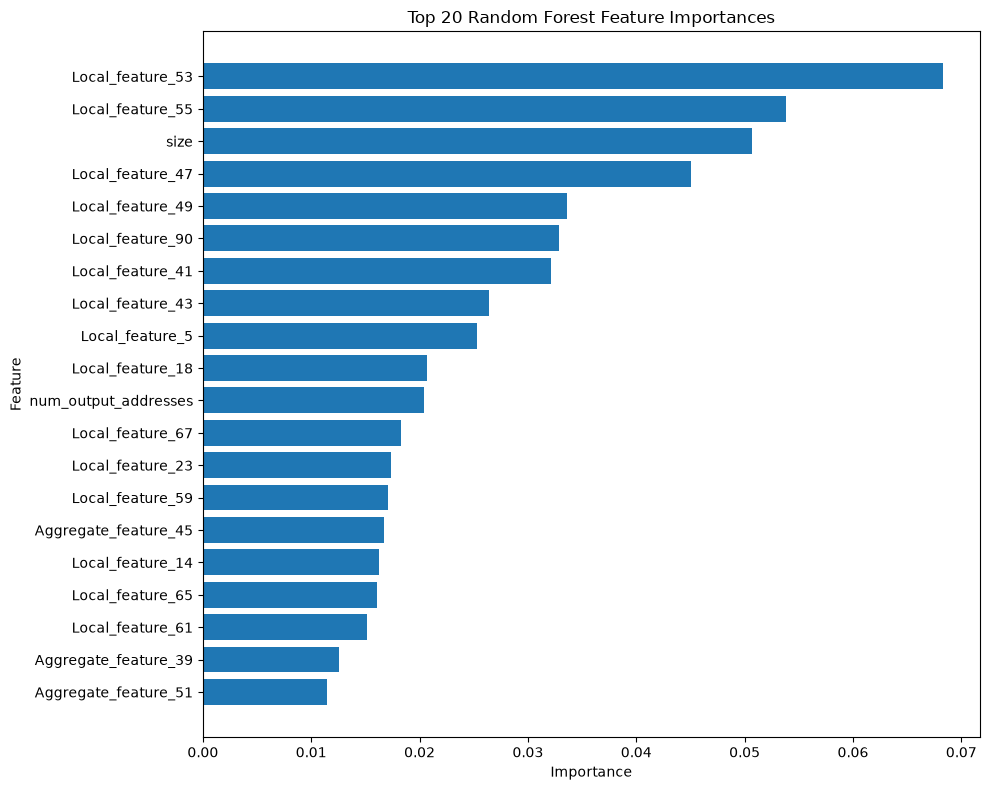

In [35]:
# ==========================================
# TOP 20 FEATURE IMPORTANCE VISUALIZATION
# ==========================================

top_features = feature_importance.head(20).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [36]:
# ==========================================
# STEP 11: FEATURE-TARGET CORRELATION CHECK
# ==========================================

# Combine training features and target
correlation_data = X_train.copy()
correlation_data["target"] = y_train.values

# Calculate correlations with target
target_correlations = (
    correlation_data.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

print("=== TOP 20 FEATURES BY ABSOLUTE TARGET CORRELATION ===")
print(
    target_correlations.head(20).to_string()
)

=== TOP 20 FEATURES BY ABSOLUTE TARGET CORRELATION ===
Local_feature_53       -0.289735
Local_feature_89       -0.251016
Local_feature_55       -0.249137
Local_feature_90       -0.243603
Local_feature_91       -0.208245
Aggregate_feature_49    0.206447
Aggregate_feature_57   -0.189548
Local_feature_52       -0.182167
Aggregate_feature_55    0.176687
Aggregate_feature_61    0.164473
Local_feature_54       -0.164201
Aggregate_feature_21   -0.157837
Aggregate_feature_63   -0.142694
Local_feature_83       -0.138263
Local_feature_85       -0.136178
Local_feature_84       -0.133202
Aggregate_feature_19    0.129683
Local_feature_77       -0.129636
Local_feature_59       -0.128262
Local_feature_65       -0.128258


In [37]:
# ==========================================
# STEP 11B: BASIC FEATURE RANGE CHECK
# ==========================================

print("=== FEATURE RANGE CHECK ===")

feature_summary = pd.DataFrame({
    "min": X_train.min(),
    "max": X_train.max(),
    "mean": X_train.mean(),
    "std": X_train.std()
})

print(feature_summary.loc[
    feature_importance.head(10)["Feature"]
].to_string())

=== FEATURE RANGE CHECK ===
                         min            max        mean          std
Local_feature_53   -0.488366       6.332689    0.941161     1.482625
Local_feature_55   -0.467583       6.430355    0.784253     1.464196
size              188.000000  445268.000000  988.601213  4651.625012
Local_feature_47   -0.243236      10.995786    0.384428     1.524811
Local_feature_49   -0.235896      11.185903    0.348690     1.513862
Local_feature_90   -0.694235       6.506444    0.477232     1.448390
Local_feature_41   -0.239368      16.682848    0.386375     1.579453
Local_feature_43   -0.234952      16.714296    0.351008     1.532416
Local_feature_5    -0.063725     260.090707    0.033090     1.883409
Local_feature_18   -0.172908      18.459601   -0.089076     0.377653


In [38]:
# ==========================================
# STEP 12: XGBOOST MODEL
# ==========================================

from xgboost import XGBClassifier

# Calculate class imbalance ratio from training data
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative class:", negative_count)
print("Positive class:", positive_count)
print("Scale positive weight:", round(scale_pos_weight, 4))

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("\nTraining XGBoost...")

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

Negative class: 32570
Positive class: 4021
Scale positive weight: 8.1

Training XGBoost...
XGBoost model trained successfully!


In [39]:
# ==========================================
# STEP 13: EVALUATE XGBOOST
# ==========================================

# Generate predictions
xgb_y_pred = xgb_model.predict(X_test)

# Generate probability scores
xgb_y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall = recall_score(y_test, xgb_y_pred)
xgb_f1 = f1_score(y_test, xgb_y_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_y_prob)
xgb_pr_auc = average_precision_score(y_test, xgb_y_prob)

print("=== XGBOOST RESULTS ===")

print(f"\nAccuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")

print("\n=== CONFUSION MATRIX ===")

xgb_cm = confusion_matrix(y_test, xgb_y_pred)
print(xgb_cm)

print("\n=== CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test,
        xgb_y_pred,
        target_names=["Licit", "Potentially Illicit"]
    )
)

=== XGBOOST RESULTS ===

Accuracy : 0.9706
Precision: 0.7516
Recall   : 0.6584
F1-Score : 0.7019
ROC-AUC  : 0.9620
PR-AUC   : 0.7848

=== CONFUSION MATRIX ===
[[9335  114]
 [ 179  345]]

=== CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

              Licit       0.98      0.99      0.98      9449
Potentially Illicit       0.75      0.66      0.70       524

           accuracy                           0.97      9973
          macro avg       0.87      0.82      0.84      9973
       weighted avg       0.97      0.97      0.97      9973



In [40]:
# Model Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        rf_recall,
        xgb_recall
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        rf_roc_auc,
        xgb_roc_auc
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        rf_pr_auc,
        xgb_pr_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.8176,0.1886,0.7481,0.3012,0.8898,0.4331
1,Random Forest,0.9762,0.9527,0.5763,0.7182,0.9578,0.7494
2,XGBoost,0.9706,0.7516,0.6584,0.7019,0.9620,0.7848


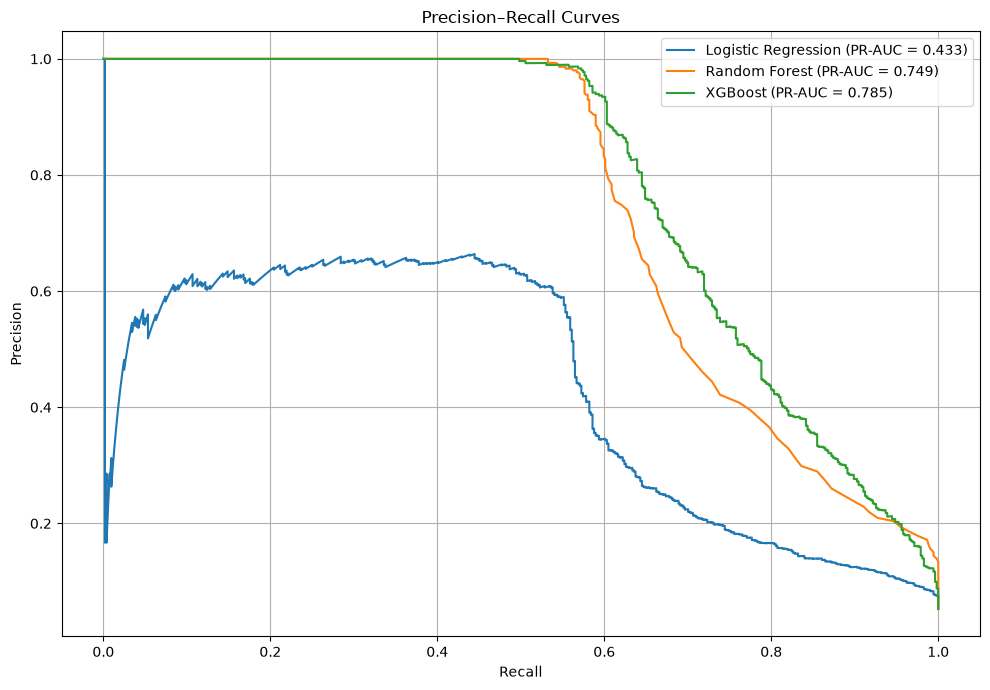

In [41]:
from sklearn.metrics import precision_recall_curve

# Calculate Precision-Recall curves
lr_precision, lr_recall, _ = precision_recall_curve(y_test, y_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_y_prob)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_y_prob)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(
    lr_recall,
    lr_precision,
    label=f"Logistic Regression (PR-AUC = {average_precision_score(y_test, y_prob):.3f})"
)

plt.plot(
    rf_recall,
    rf_precision,
    label=f"Random Forest (PR-AUC = {rf_pr_auc:.3f})"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label=f"XGBoost (PR-AUC = {xgb_pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

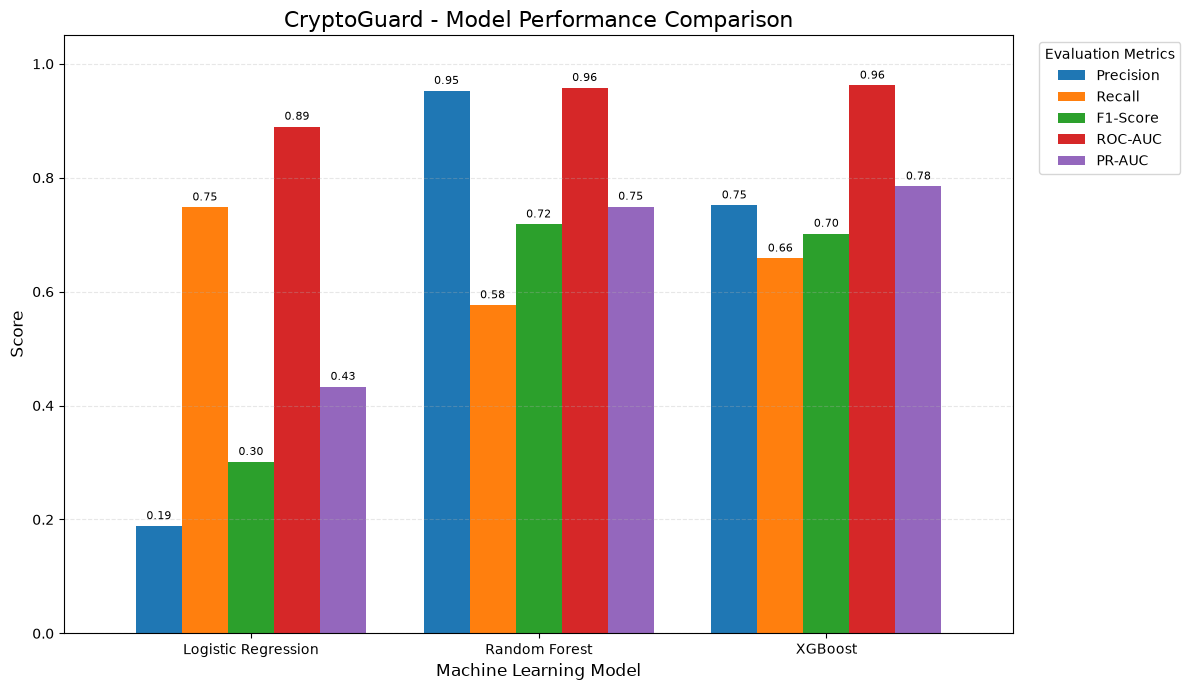

In [42]:
# Model Performance Comparison

metrics = ["Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]

model_comparison_plot = model_comparison.set_index("Model")[metrics]

ax = model_comparison_plot.plot(
    kind="bar",
    figsize=(12, 7),
    width=0.8
)

plt.title("CryptoGuard - Model Performance Comparison", fontsize=16)
plt.xlabel("Machine Learning Model", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.ylim(0, 1.05)

plt.xticks(rotation=0)
plt.legend(
    title="Evaluation Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.3)

# Add values above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

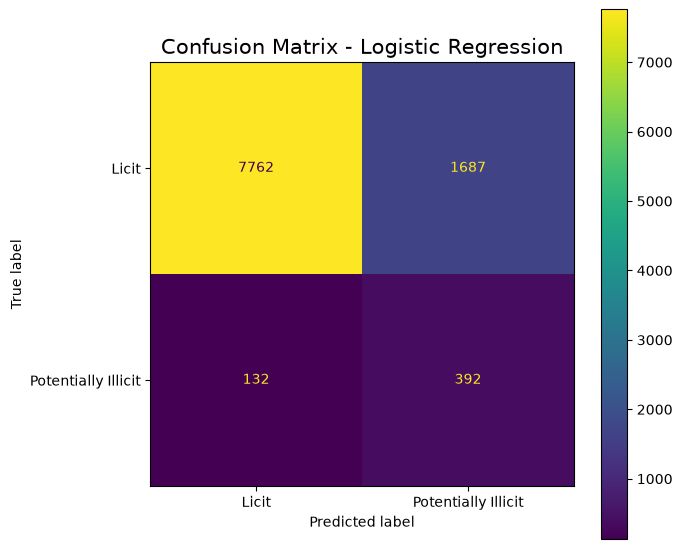

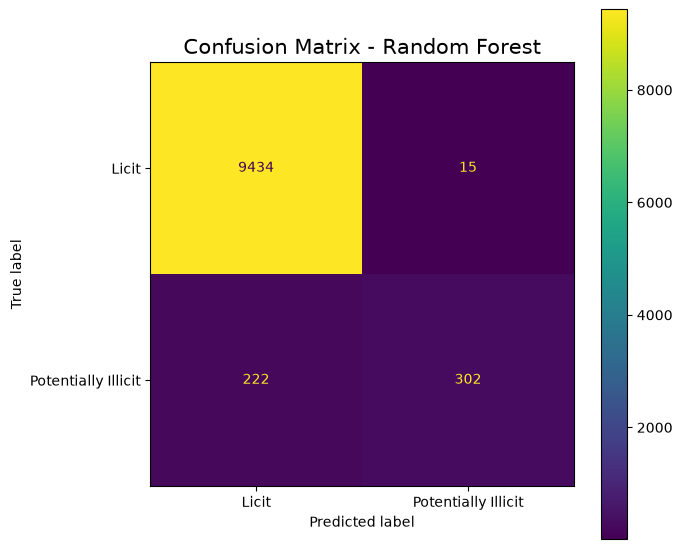

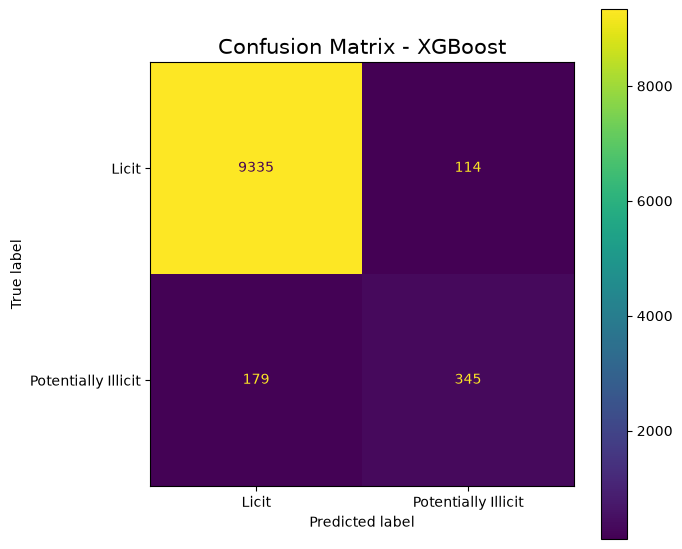

In [43]:
# Confusion Matrix Comparison

from sklearn.metrics import ConfusionMatrixDisplay

# Store confusion matrices
lr_cm = confusion_matrix(y_test, y_pred)
rf_cm = confusion_matrix(y_test, rf_y_pred)
xgb_cm = confusion_matrix(y_test, xgb_y_pred)

# Create three separate figures
confusion_matrices = {
    "Logistic Regression": lr_cm,
    "Random Forest": rf_cm,
    "XGBoost": xgb_cm
}

for model_name, cm in confusion_matrices.items():

    fig, ax = plt.subplots(figsize=(7, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Licit", "Potentially Illicit"]
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=True
    )

    ax.set_title(
        f"Confusion Matrix - {model_name}",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

In [44]:
# Detection vs Missed vs False Alerts

detection_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Detected": [
        lr_cm[1, 1],
        rf_cm[1, 1],
        xgb_cm[1, 1]
    ],
    "Missed": [
        lr_cm[1, 0],
        rf_cm[1, 0],
        xgb_cm[1, 0]
    ],
    "False Alerts": [
        lr_cm[0, 1],
        rf_cm[0, 1],
        xgb_cm[0, 1]
    ]
})

print(detection_summary)

                 Model  Detected  Missed  False Alerts
0  Logistic Regression       392     132          1687
1        Random Forest       302     222            15
2              XGBoost       345     179           114


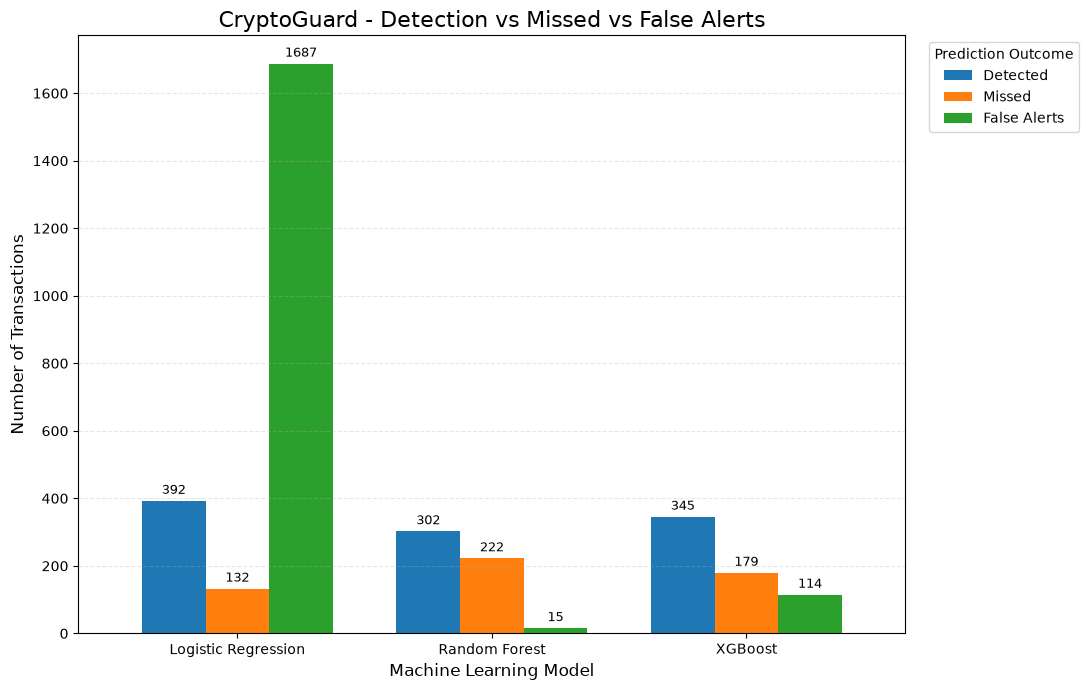

In [45]:
# Plot Detection vs Missed vs False Alerts

plot_data = detection_summary.set_index("Model")

ax = plot_data.plot(
    kind="bar",
    figsize=(11, 7),
    width=0.75
)

plt.title(
    "CryptoGuard - Detection vs Missed vs False Alerts",
    fontsize=16
)

plt.xlabel("Machine Learning Model", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

plt.xticks(rotation=0)

plt.legend(
    title="Prediction Outcome",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [46]:
# XGBoost Feature Importance

xgb_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

# Display top 20 features
xgb_feature_importance.head(20)

,Feature,Importance
169,size,0.191364
58,Local_feature_59,0.064824
45,Local_feature_46,0.057013
80,Local_feature_81,0.037634
64,Local_feature_65,0.036844
162,Aggregate_feature_70,0.034698
52,Local_feature_53,0.024872
89,Local_feature_90,0.021283
79,Local_feature_80,0.019981
160,Aggregate_feature_68,0.019806


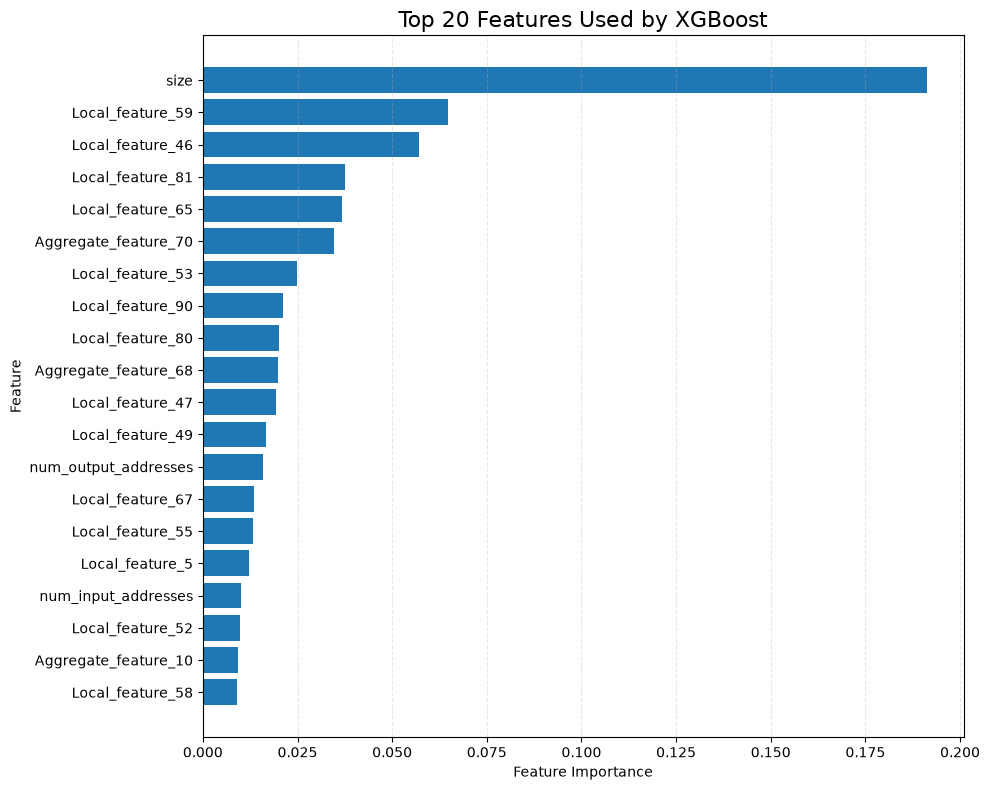

In [47]:
# Plot Top 20 XGBoost Features

top_xgb_features = (
    xgb_feature_importance
    .head(20)
    .sort_values(by="Importance", ascending=True)
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_xgb_features["Feature"],
    top_xgb_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 20 Features Used by XGBoost",
    fontsize=16
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

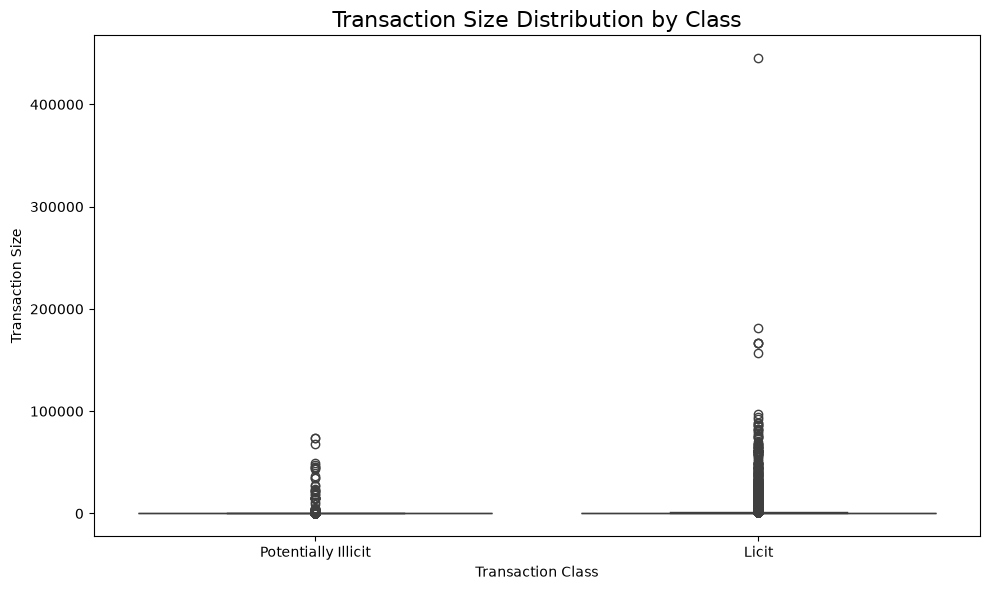

In [48]:
# Transaction Size Distribution by Class

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=labeled_data,
    x="class",
    y="size"
)

plt.xlabel("Transaction Class")
plt.ylabel("Transaction Size")
plt.title(
    "Transaction Size Distribution by Class",
    fontsize=16
)

plt.xticks(
    [0, 1],
    ["Potentially Illicit", "Licit"]
)

plt.tight_layout()
plt.show()

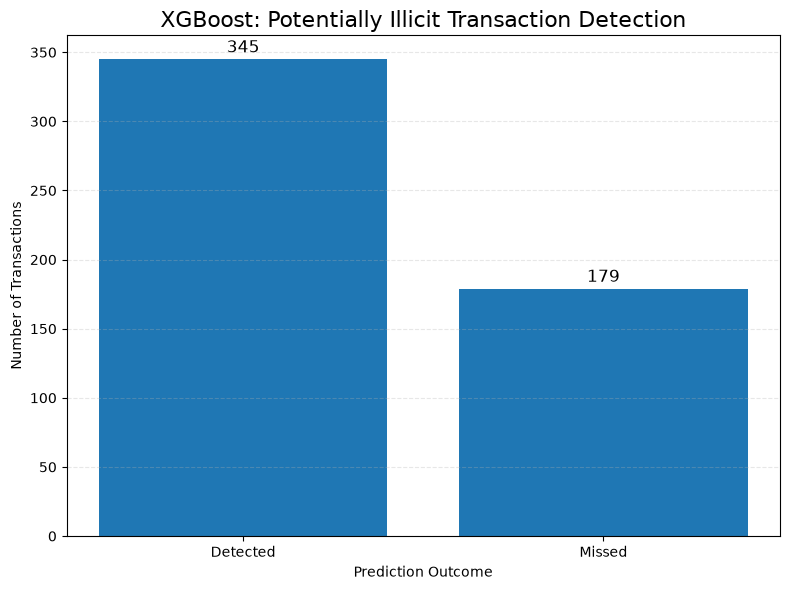

In [49]:
# XGBoost Detection Breakdown

detected = xgb_cm[1, 1]
missed = xgb_cm[1, 0]

labels = ["Detected", "Missed"]
values = [detected, missed]

plt.figure(figsize=(8, 6))

bars = plt.bar(labels, values)

plt.title(
    "XGBoost: Potentially Illicit Transaction Detection",
    fontsize=16
)

plt.xlabel("Prediction Outcome")
plt.ylabel("Number of Transactions")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5,
        str(value),
        ha="center",
        fontsize=12
    )

plt.tight_layout()
plt.show()

In [50]:
import joblib

xgb_model = joblib.load(
    r"C:\CryptoGuard\models\xgboost_model.pkl"
)

print("XGBoost model loaded successfully!")

XGBoost model loaded successfully!


In [7]:
# SHAP Explainability

import shap

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Use the same imputed test data used by the model
X_test_sample = X_test_imputed.sample(
    n=min(2000, len(X_test_imputed)),
    random_state=42
)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated successfully!")
print("Sample size:", X_test_sample.shape)

SHAP values calculated successfully!
Sample size: (2000, 182)


In [8]:
# Generate SHAP explanation for transaction 30157957

transaction_id = 30157957

# Find the transaction in the test data
matching_indices = test_data.index[
    test_data["txId"] == transaction_id
]

if len(matching_indices) == 0:
    print("Transaction not found in the test dataset.")
else:
    transaction_index = matching_indices[0]

    # Get the transaction's model features
    transaction = X_test_imputed.loc[[transaction_index]]

    # Generate SHAP explanation
    transaction_shap = explainer(transaction)

    print("Local SHAP explanation generated successfully!")
    print("Transaction:", transaction_id)
    print("Number of features:", transaction.shape[1])

Transaction not found in the test dataset.


In [9]:
print("SHAP artifact already generated for transaction:")
print(12661353)

shap_transaction = pd.read_csv(
    r"C:\CryptoGuard\Data\processed\shap_transaction_12661353.csv"
)

print("Shape:", shap_transaction.shape)
print("\nTop 5 SHAP features:")
print(
    shap_transaction
    .assign(abs_shap=shap_transaction["shap_value"].abs())
    .sort_values("abs_shap", ascending=False)
    [["feature", "shap_value", "feature_value"]]
    .head(5)
)

SHAP artifact already generated for transaction:
12661353
Shape: (182, 3)

Top 5 SHAP features:
                  feature  shap_value  feature_value
169                  size    2.501198     192.000000
52       Local_feature_53    0.757184      -0.488239
160  Aggregate_feature_68    0.707354      -0.125939
89       Local_feature_90    0.644511      -0.694235
162  Aggregate_feature_70    0.481809      -0.269818


In [4]:
import joblib

xgb_model = joblib.load(
    r"C:\CryptoGuard\models\xgboost_model.pkl"
)

print("XGBoost model loaded successfully!")

XGBoost model loaded successfully!


In [6]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Load the original dataset
features = pd.read_csv(
    r"C:\CryptoGuard\Data\raw\txs_features.txt"
)

classes = pd.read_csv(
    r"C:\CryptoGuard\Data\raw\txs_classes.txt"
)

# Merge features and class labels
data = features.merge(
    classes,
    on="txId",
    how="inner"
)

# Keep only labeled transactions
labeled_data = data[
    data["class"].isin([1, 2])
].copy()

# Chronological train/test split
train_data = labeled_data[
    labeled_data["Time step"] <= 40
].copy()

test_data = labeled_data[
    labeled_data["Time step"] > 40
].copy()

# Select model features
feature_columns = [
    col for col in labeled_data.columns
    if col not in ["txId", "Time step", "class"]
]

X_train = train_data[feature_columns]
X_test = test_data[feature_columns]

y_train = train_data["class"]
y_test = test_data["class"]

# Median imputation
imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=feature_columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=feature_columns,
    index=X_test.index
)

print("Test data restored successfully!")
print("X_test_imputed shape:", X_test_imputed.shape)
print("Missing values:", X_test_imputed.isna().sum().sum())

Test data restored successfully!
X_test_imputed shape: (9973, 182)
Missing values: 0


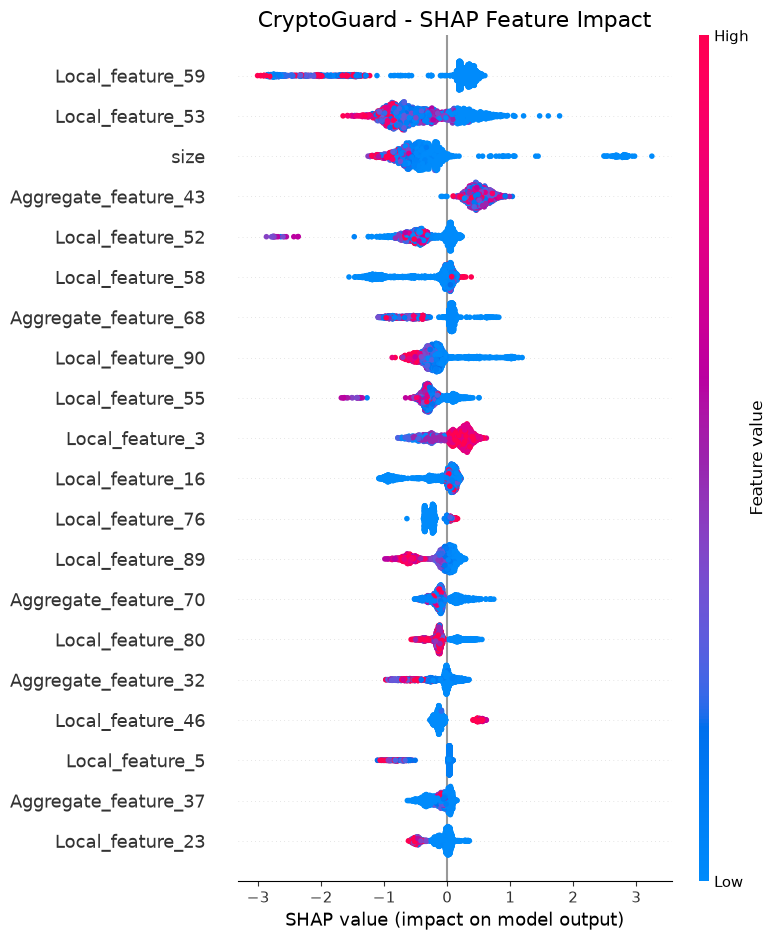

In [52]:
# SHAP Summary Plot

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    X_test_sample,
    max_display=20,
    show=False
)

plt.title(
    "CryptoGuard - SHAP Feature Impact",
    fontsize=16
)

plt.tight_layout()
plt.show()

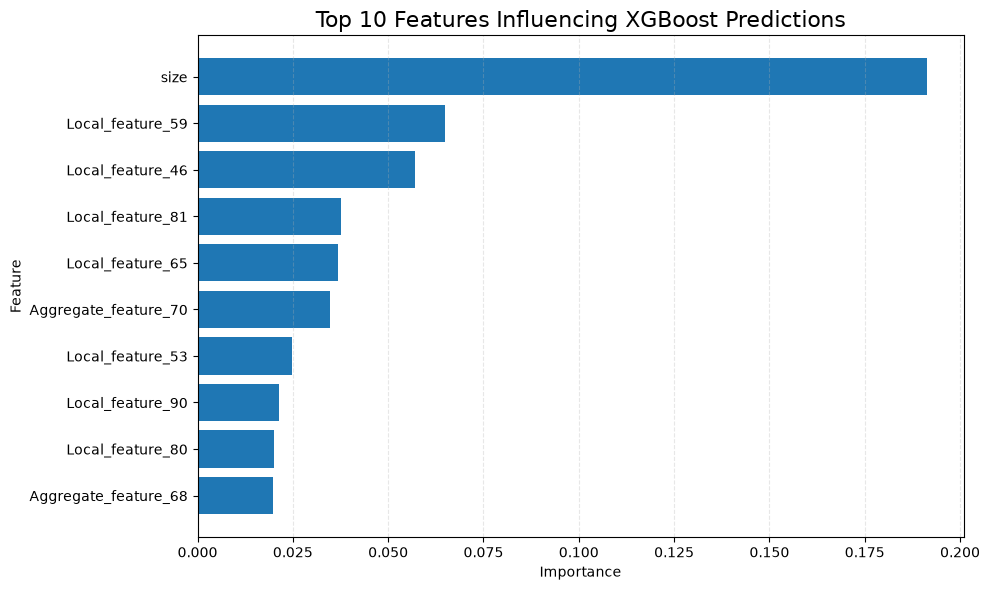

In [53]:
# Top 10 XGBoost Feature Importance

top_10 = (
    xgb_feature_importance
    .head(10)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    "Top 10 Features Influencing XGBoost Predictions",
    fontsize=16
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [54]:
# SHAP Global Feature Importance

shap_importance = pd.DataFrame({
    "Feature": X_test_sample.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
)

# Display top 20 features
shap_importance.head(20)

,Feature,Mean_Absolute_SHAP
58,Local_feature_59,0.703208
52,Local_feature_53,0.567663
169,size,0.538464
135,Aggregate_feature_43,0.502855
51,Local_feature_52,0.373957
57,Local_feature_58,0.323906
160,Aggregate_feature_68,0.300391
89,Local_feature_90,0.300072
54,Local_feature_55,0.269277
2,Local_feature_3,0.266708


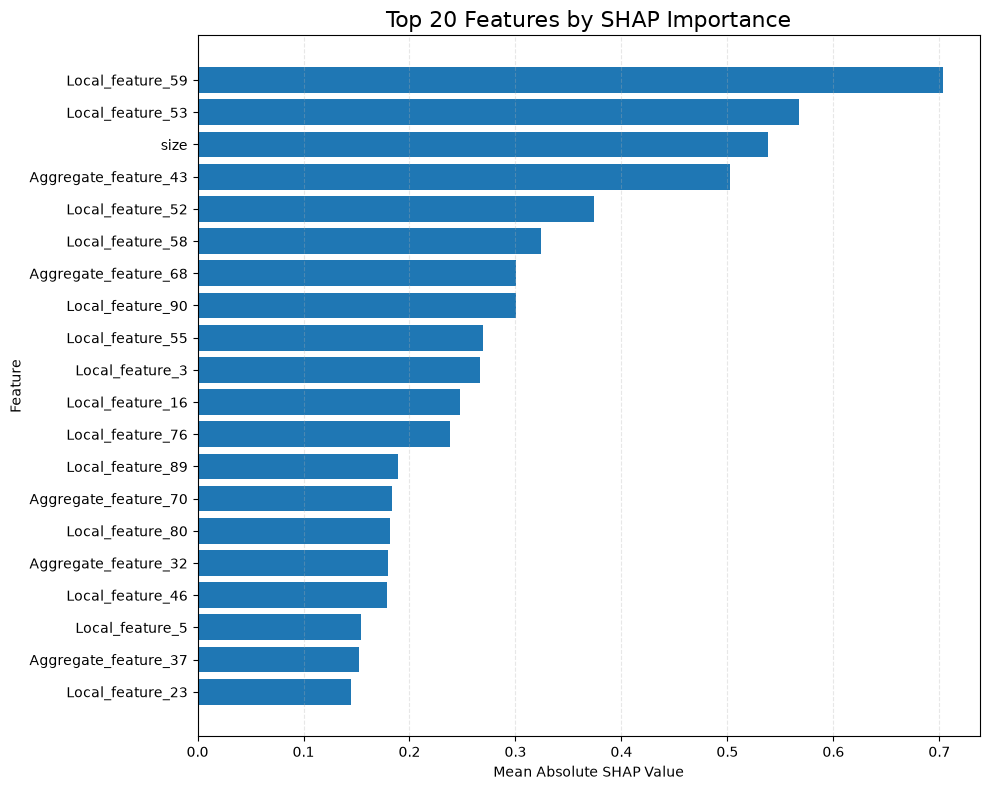

In [55]:
# Plot Top 20 SHAP Features

top_shap_features = (
    shap_importance
    .head(20)
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_shap_features["Feature"],
    top_shap_features["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title(
    "Top 20 Features by SHAP Importance",
    fontsize=16
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

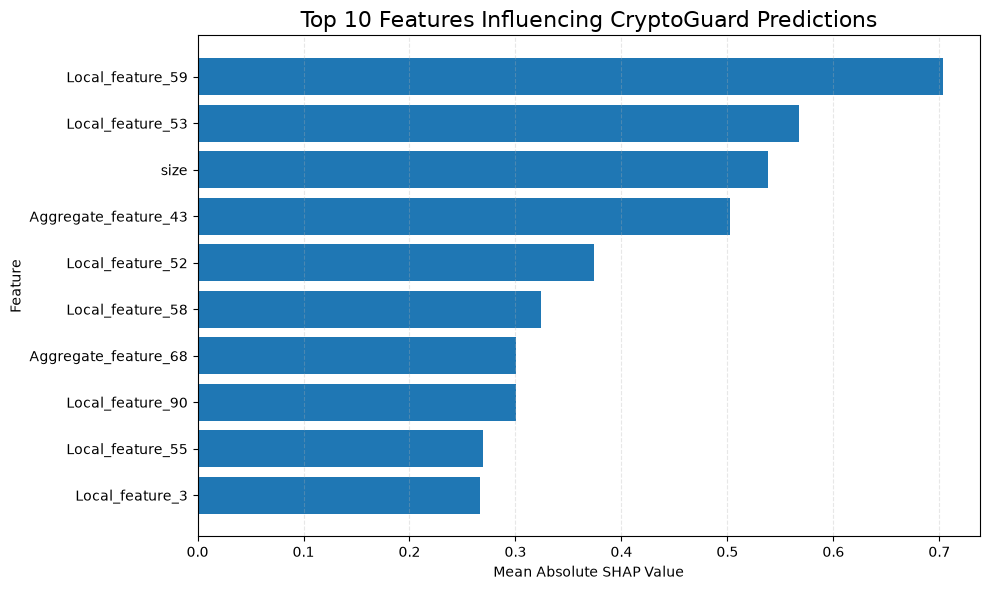

In [56]:
# Top 10 SHAP Feature Importance

top_10_shap = (
    shap_importance
    .head(10)
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_shap["Feature"],
    top_10_shap["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title(
    "Top 10 Features Influencing CryptoGuard Predictions",
    fontsize=16
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [57]:
# Select a correctly detected potentially illicit transaction
sample_predictions = xgb_model.predict(X_test_sample)

sample_actual = y_test.loc[X_test_sample.index]

true_positive_indices = X_test_sample.index[
    (sample_predictions == 1) & (sample_actual == 1)
]

transaction_index = true_positive_indices[0]

transaction_id = test_tx_ids.loc[transaction_index]
actual_class = y_test.loc[transaction_index]

transaction_probability = xgb_model.predict_proba(
    X_test_sample.loc[[transaction_index]]
)[0, 1]

print("Selected Transaction")
print("--------------------")
print("Transaction ID:", transaction_id)
print("Actual Class:", "Potentially Illicit" if actual_class == 1 else "Licit")
print("Predicted Probability:", round(transaction_probability, 4))
print("Predicted Risk:", "Potentially Illicit" if transaction_probability >= 0.5 else "Licit")

Selected Transaction
--------------------
Transaction ID: 12661353
Actual Class: Potentially Illicit
Predicted Probability: 0.9974
Predicted Risk: Potentially Illicit


In [58]:
# Generate SHAP explanation for the selected transaction

transaction = X_test_sample.loc[[transaction_index]]

transaction_shap = explainer(transaction)

print("Local SHAP explanation generated successfully!")
print("Transaction:", transaction_id)
print("Number of features:", transaction.shape[1])

Local SHAP explanation generated successfully!
Transaction: 12661353
Number of features: 182


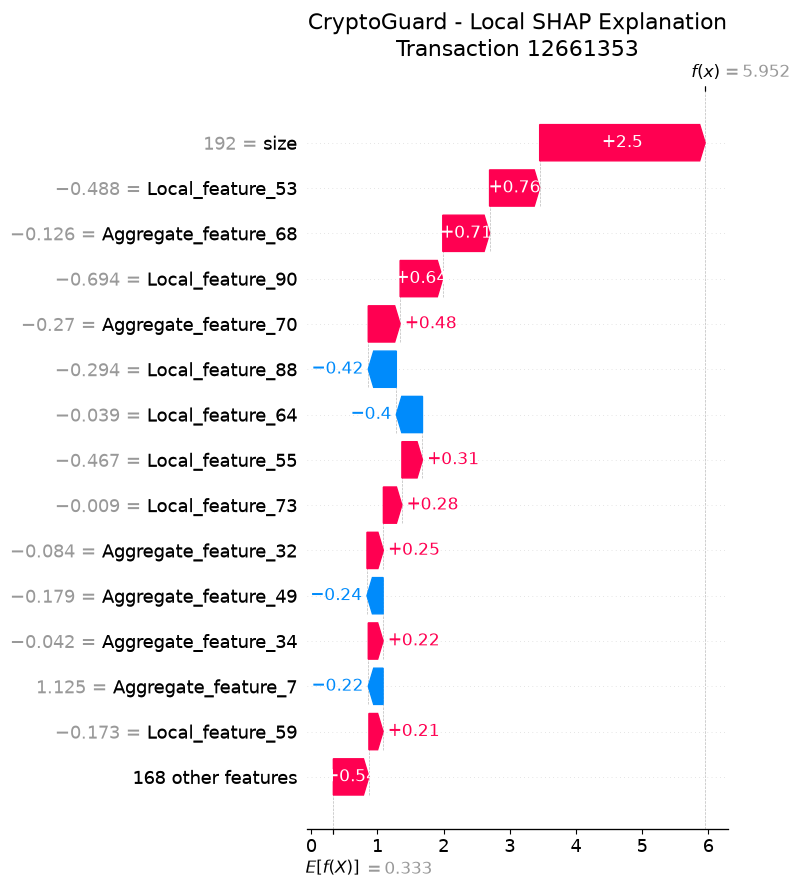

In [59]:
# SHAP waterfall plot for the selected transaction

plt.figure(figsize=(12, 8))

shap.plots.waterfall(
    transaction_shap[0],
    max_display=15,
    show=False
)

plt.title(
    "CryptoGuard - Local SHAP Explanation\nTransaction 12661353",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [60]:
# Save SHAP explanation for the selected transaction

import pandas as pd
import os

shap_data = pd.DataFrame({
    "feature": transaction.columns,
    "shap_value": transaction_shap.values[0],
    "feature_value": transaction.iloc[0].values
})

shap_path = r"C:\CryptoGuard\Data\processed\shap_transaction_12661353.csv"

shap_data.to_csv(shap_path, index=False)

print("SHAP explanation saved successfully!")
print("Saved to:", shap_path)
print("Rows:", len(shap_data))

SHAP explanation saved successfully!
Saved to: C:\CryptoGuard\Data\processed\shap_transaction_12661353.csv
Rows: 182


In [61]:
# ==========================================
# Step 3A - Prepare Data for Anomaly Detection
# ==========================================

from sklearn.ensemble import IsolationForest

# Use unknown transactions (Class 3)
anomaly_data = unknown_data.copy()

# Keep transaction IDs separately
anomaly_tx_ids = anomaly_data["txId"].copy()

# Remove identifier, time, and class columns
X_anomaly = anomaly_data.drop(
    columns=["txId", "Time step", "class"]
)

# Apply the same training-set medians used earlier
X_anomaly = X_anomaly.fillna(train_medians)

print("Anomaly detection data prepared successfully!")
print("Transactions:", X_anomaly.shape[0])
print("Features:", X_anomaly.shape[1])
print("Missing values:", X_anomaly.isnull().sum().sum())

Anomaly detection data prepared successfully!
Transactions: 157205
Features: 182
Missing values: 0


In [62]:
# ==========================================
# Step 3B - Train Isolation Forest
# ==========================================

from sklearn.ensemble import IsolationForest

# Train anomaly detector on the labeled training data
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(X_train)

print("Isolation Forest trained successfully!")
print("Trees:", isolation_forest.n_estimators)

Isolation Forest trained successfully!
Trees: 200


In [63]:
# ==========================================
# Step 3C - Calculate Anomaly Scores
# ==========================================

# Isolation Forest anomaly scores
anomaly_scores = isolation_forest.decision_function(X_anomaly)

# Convert scores so that higher = more anomalous
anomaly_risk_score = -anomaly_scores

# Create results table
anomaly_results = pd.DataFrame({
    "txId": anomaly_tx_ids.values,
    "Anomaly_Score": anomaly_risk_score
})

# Sort from most anomalous to least anomalous
anomaly_results = anomaly_results.sort_values(
    by="Anomaly_Score",
    ascending=False
).reset_index(drop=True)

print("Anomaly scoring completed!")
print("Transactions scored:", len(anomaly_results))
print("\nTop 10 most anomalous transactions:")
display(anomaly_results.head(10))

Anomaly scoring completed!
Transactions scored: 157205

Top 10 most anomalous transactions:


,txId,Anomaly_Score
0,94676334,0.166742
1,314773565,0.148655
2,372980774,0.138266
3,372962974,0.135191
4,33453300,0.128309
5,372750942,0.123827
6,33404530,0.122947
7,277458870,0.119753
8,89913568,0.117874
9,272117547,0.110025


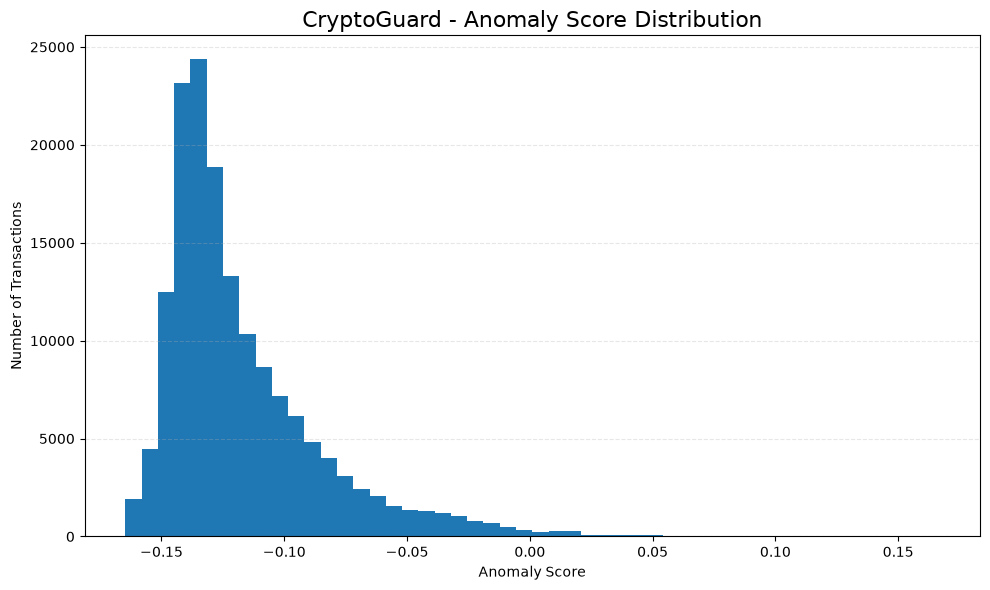

In [64]:
# ==========================================
# Step 3D - Anomaly Score Distribution
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    anomaly_results["Anomaly_Score"],
    bins=50
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Transactions")
plt.title(
    "CryptoGuard - Anomaly Score Distribution",
    fontsize=16
)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
# ==========================================
# Step 3E - Calculate Anomaly Thresholds
# ==========================================

percentiles = [90, 95, 99, 99.5, 99.9]

thresholds = np.percentile(
    anomaly_results["Anomaly_Score"],
    percentiles
)

threshold_table = pd.DataFrame({
    "Percentile": percentiles,
    "Anomaly_Threshold": thresholds
})

print("Anomaly threshold analysis:")
display(threshold_table)

print("\nNumber of transactions above each threshold:")

for percentile, threshold in zip(percentiles, thresholds):
    count = (anomaly_results["Anomaly_Score"] >= threshold).sum()
    percentage = (count / len(anomaly_results)) * 100
    
    print(
        f"{percentile}th percentile: "
        f"{count:,} transactions ({percentage:.2f}%)"
    )

Anomaly threshold analysis:


,Percentile,Anomaly_Threshold
0,90.0,-0.074786
1,95.0,-0.049173
2,99.0,-0.005901
3,99.5,0.013638
4,99.9,0.047715



Number of transactions above each threshold:
90th percentile: 15,721 transactions (10.00%)
95th percentile: 7,861 transactions (5.00%)
99th percentile: 1,573 transactions (1.00%)
99.5th percentile: 789 transactions (0.50%)
99.9th percentile: 160 transactions (0.10%)


In [66]:
# ==========================================
# Step 3F - Create Anomaly Flags
# ==========================================

# Use the 99th percentile as the anomaly threshold
anomaly_threshold = np.percentile(
    anomaly_results["Anomaly_Score"],
    99
)

# Create anomaly flag
anomaly_results["Anomaly_Flag"] = (
    anomaly_results["Anomaly_Score"] >= anomaly_threshold
).astype(int)

# Count flagged transactions
flagged_count = anomaly_results["Anomaly_Flag"].sum()
total_count = len(anomaly_results)
flagged_percentage = (flagged_count / total_count) * 100

print("Anomaly detection threshold:", round(anomaly_threshold, 6))
print("Flagged transactions:", flagged_count)
print("Total transactions:", total_count)
print("Flagged percentage:", round(flagged_percentage, 2), "%")

print("\nTop 10 flagged transactions:")
display(
    anomaly_results[
        anomaly_results["Anomaly_Flag"] == 1
    ].head(10)
)

Anomaly detection threshold: -0.005901
Flagged transactions: 1573
Total transactions: 157205
Flagged percentage: 1.0 %

Top 10 flagged transactions:


,txId,Anomaly_Score,Anomaly_Flag
0,94676334,0.166742,1
1,314773565,0.148655,1
2,372980774,0.138266,1
3,372962974,0.135191,1
4,33453300,0.128309,1
5,372750942,0.123827,1
6,33404530,0.122947,1
7,277458870,0.119753,1
8,89913568,0.117874,1
9,272117547,0.110025,1


In [67]:
# ==========================================
# Step 4A - XGBoost Risk Scores
# ==========================================

# Generate XGBoost probability scores for unknown transactions
xgb_unknown_probability = xgb_model.predict_proba(X_anomaly)[:, 1]

# Create risk results table
risk_results = pd.DataFrame({
    "txId": anomaly_tx_ids.values,
    "XGB_Risk_Score": xgb_unknown_probability,
    "Anomaly_Score": anomaly_results["Anomaly_Score"].values,
    "Anomaly_Flag": anomaly_results["Anomaly_Flag"].values
})

print("XGBoost risk scoring completed!")
print("Transactions scored:", len(risk_results))

display(risk_results.head(10))

XGBoost risk scoring completed!
Transactions scored: 157205


,txId,XGB_Risk_Score,Anomaly_Score,Anomaly_Flag
0,3321,0.003904,0.166742,1
1,11108,0.019652,0.148655,1
2,51816,0.072350,0.138266,1
3,195142,0.033556,0.135191,1
4,223263,0.004732,0.128309,1
5,223265,0.000121,0.123827,1
6,245992,0.000080,0.122947,1
7,267260,0.001808,0.119753,1
8,267262,0.002331,0.117874,1
9,293346,0.001945,0.110025,1


In [68]:
# ==========================================
# Step 4A - Correctly Align Risk Scores
# ==========================================

# Generate XGBoost probability scores for unknown transactions
xgb_unknown_probability = xgb_model.predict_proba(X_anomaly)[:, 1]

# Create XGBoost results in the ORIGINAL transaction order
xgb_results = pd.DataFrame({
    "txId": anomaly_tx_ids.values,
    "XGB_Risk_Score": xgb_unknown_probability
})

# Merge with anomaly results using txId
risk_results = anomaly_results.merge(
    xgb_results,
    on="txId",
    how="inner",
    validate="one_to_one"
)

# Reorder columns
risk_results = risk_results[
    [
        "txId",
        "XGB_Risk_Score",
        "Anomaly_Score",
        "Anomaly_Flag"
    ]
]

print("Risk scores correctly aligned!")
print("Transactions:", len(risk_results))

print("\nTop 10 most anomalous transactions:")
display(risk_results.head(10))


Risk scores correctly aligned!
Transactions: 157205

Top 10 most anomalous transactions:


,txId,XGB_Risk_Score,Anomaly_Score,Anomaly_Flag
0,94676334,0.000087,0.166742,1
1,314773565,0.000018,0.148655,1
2,372980774,0.000146,0.138266,1
3,372962974,0.000047,0.135191,1
4,33453300,0.000050,0.128309,1
5,372750942,0.000045,0.123827,1
6,33404530,0.000066,0.122947,1
7,277458870,0.000082,0.119753,1
8,89913568,0.000031,0.117874,1
9,272117547,0.000056,0.110025,1


In [69]:
# ==========================================
# Step 4B - Combined CryptoGuard Risk Score
# ==========================================

# Normalize anomaly scores to a 0-1 range
anomaly_min = risk_results["Anomaly_Score"].min()
anomaly_max = risk_results["Anomaly_Score"].max()

risk_results["Normalized_Anomaly_Score"] = (
    (risk_results["Anomaly_Score"] - anomaly_min)
    / (anomaly_max - anomaly_min)
)

# Combine the two independent signals
# 70% supervised ML + 30% anomaly detection
risk_results["Combined_Risk_Score"] = (
    0.70 * risk_results["XGB_Risk_Score"]
    + 0.30 * risk_results["Normalized_Anomaly_Score"]
)

# Sort by combined risk
risk_results = risk_results.sort_values(
    by="Combined_Risk_Score",
    ascending=False
).reset_index(drop=True)

print("Combined CryptoGuard risk score created!")

print("\nTop 10 highest-risk transactions:")
display(
    risk_results[
        [
            "txId",
            "XGB_Risk_Score",
            "Anomaly_Score",
            "Normalized_Anomaly_Score",
            "Combined_Risk_Score",
            "Anomaly_Flag"
        ]
    ].head(10)
)

Combined CryptoGuard risk score created!

Top 10 highest-risk transactions:


,txId,XGB_Risk_Score,Anomaly_Score,Normalized_Anomaly_Score,Combined_Risk_Score,Anomaly_Flag
0,30157957,0.996910,-0.027111,0.415177,0.822390,0
1,31168505,0.988690,-0.021163,0.433123,0.822020,0
2,66665998,0.993992,-0.027479,0.414068,0.820015,0
3,100832039,0.994929,-0.036303,0.387446,0.812684,0
4,196255586,0.998077,-0.045113,0.360869,0.806915,0
5,197480855,0.994542,-0.044764,0.361921,0.804756,0
6,288315659,0.995744,-0.046867,0.355579,0.803694,0
7,66666000,0.992715,-0.044878,0.361579,0.803375,0
8,39371673,0.998641,-0.050950,0.343261,0.802027,0
9,99936400,0.998912,-0.051400,0.341901,0.801809,0


In [70]:
# ==========================================
# Step 4C - Combined Risk Distribution
# ==========================================

risk_percentiles = [50, 75, 90, 95, 99, 99.5, 99.9]

combined_thresholds = np.percentile(
    risk_results["Combined_Risk_Score"],
    risk_percentiles
)

combined_risk_table = pd.DataFrame({
    "Percentile": risk_percentiles,
    "Combined_Risk_Threshold": combined_thresholds
})

print("Combined risk score distribution:")
display(combined_risk_table)

print("\nCombined risk score statistics:")
print(
    risk_results["Combined_Risk_Score"].describe()
)

Combined risk score distribution:


,Percentile,Combined_Risk_Threshold
0,50.0,0.064387
1,75.0,0.123043
2,90.0,0.346187
3,95.0,0.560554
4,99.0,0.716366
5,99.5,0.732168
6,99.9,0.760286



Combined risk score statistics:
count    157205.000000
mean          0.127226
std           0.160985
min           0.000717
25%           0.038970
50%           0.064387
75%           0.123043
max           0.822390
Name: Combined_Risk_Score, dtype: float64


In [71]:
# ==========================================
# Step 4D - CryptoGuard Risk Categories
# ==========================================

# Use observed percentile thresholds
medium_threshold = np.percentile(
    risk_results["Combined_Risk_Score"],
    95
)

high_threshold = np.percentile(
    risk_results["Combined_Risk_Score"],
    99
)

# Create risk categories
risk_results["Risk_Category"] = np.select(
    [
        risk_results["Combined_Risk_Score"] >= high_threshold,
        risk_results["Combined_Risk_Score"] >= medium_threshold
    ],
    [
        "High Risk",
        "Medium Risk"
    ],
    default="Low Risk"
)

# Count categories
risk_category_summary = (
    risk_results["Risk_Category"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    .reset_index()
)

risk_category_summary.columns = [
    "Risk_Category",
    "Transaction_Count"
]

risk_category_summary["Percentage"] = (
    risk_category_summary["Transaction_Count"]
    / len(risk_results)
    * 100
)

print("CryptoGuard risk categories created!")

print("\nThresholds:")
print("Medium Risk threshold:", round(medium_threshold, 6))
print("High Risk threshold:", round(high_threshold, 6))

print("\nRisk category distribution:")
display(risk_category_summary)

CryptoGuard risk categories created!

Thresholds:
Medium Risk threshold: 0.560554
High Risk threshold: 0.716366

Risk category distribution:


,Risk_Category,Transaction_Count,Percentage
0,Low Risk,149344,94.999523
1,Medium Risk,6288,3.999873
2,High Risk,1573,1.000604


In [72]:
# ==========================================
# Step 5A - Build Blockchain Transaction Graph
# ==========================================

import networkx as nx

# Create directed transaction graph
transaction_graph = nx.from_pandas_edgelist(
    edges,
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph()
)

print("Blockchain transaction graph created!")
print("------------------------------------")
print("Nodes:", transaction_graph.number_of_nodes())
print("Edges:", transaction_graph.number_of_edges())

Blockchain transaction graph created!
------------------------------------
Nodes: 203769
Edges: 234355


In [73]:
# ==========================================
# Step 5B - Network Feature Extraction
# ==========================================

# Number of incoming connections
in_degree = dict(transaction_graph.in_degree())

# Number of outgoing connections
out_degree = dict(transaction_graph.out_degree())

# Total connections
total_degree = dict(transaction_graph.degree())

# Add network features to the risk analysis data
risk_results["In_Degree"] = risk_results["txId"].map(in_degree).fillna(0)
risk_results["Out_Degree"] = risk_results["txId"].map(out_degree).fillna(0)
risk_results["Total_Degree"] = risk_results["txId"].map(total_degree).fillna(0)

print("Network features calculated successfully!")
print("-----------------------------------------")
print("Transactions analyzed:", len(risk_results))
print("Missing network values:", 
      risk_results[["In_Degree", "Out_Degree", "Total_Degree"]].isnull().sum().sum())

print("\nNetwork feature summary:")
display(
    risk_results[
        ["In_Degree", "Out_Degree", "Total_Degree"]
    ].describe()
)

Network features calculated successfully!
-----------------------------------------
Transactions analyzed: 157205
Missing network values: 0

Network feature summary:


,In_Degree,Out_Degree,Total_Degree
count,157205.000000,157205.000000,157205.000000
mean,0.943685,1.152362,2.096047
std,2.136958,1.349530,2.528148
min,0.000000,0.000000,1.000000
25%,0.000000,1.000000,1.000000
50%,1.000000,1.000000,2.000000
75%,1.000000,1.000000,2.000000
max,212.000000,122.000000,212.000000


In [74]:
# ==========================================
# Step 5C - Network Activity Score
# ==========================================

# Calculate percentile rank of network connectivity
risk_results["Network_Activity_Score"] = (
    risk_results["Total_Degree"]
    .rank(pct=True)
)

# Create a final investigation score
risk_results["Investigation_Score"] = (
    0.60 * risk_results["XGB_Risk_Score"]
    + 0.20 * risk_results["Normalized_Anomaly_Score"]
    + 0.20 * risk_results["Network_Activity_Score"]
)

# Sort by investigation priority
risk_results = risk_results.sort_values(
    by="Investigation_Score",
    ascending=False
).reset_index(drop=True)

print("Network activity score created!")
print("--------------------------------")

print(
    "Investigation score range:",
    round(risk_results["Investigation_Score"].min(), 6),
    "to",
    round(risk_results["Investigation_Score"].max(), 6)
)

print("\nTop 10 investigation-priority transactions:")

display(
    risk_results[
        [
            "txId",
            "XGB_Risk_Score",
            "Anomaly_Score",
            "Network_Activity_Score",
            "Investigation_Score"
        ]
    ].head(10)
)


Network activity score created!
--------------------------------
Investigation score range: 0.033523 to 0.881076

Top 10 investigation-priority transactions:


,txId,XGB_Risk_Score,Anomaly_Score,Network_Activity_Score,Investigation_Score
0,30157957,0.996910,-0.027111,0.999472,0.881076
1,31168505,0.988690,-0.021163,0.999870,0.879813
2,66665998,0.993992,-0.027479,0.999656,0.879140
3,100832039,0.994929,-0.036303,0.999835,0.874414
4,197480855,0.994542,-0.044764,0.999618,0.869033
5,288315659,0.995744,-0.046867,0.999736,0.868509
6,66666000,0.992715,-0.044878,0.998760,0.867697
7,31168341,0.987862,-0.052401,0.999472,0.860388
8,37341170,0.995689,-0.068477,0.999348,0.855360
9,382997214,0.989094,-0.062430,0.999930,0.855168


In [75]:
# ==========================================
# Step 5D - Risk Signal Relationship Analysis
# ==========================================

signal_columns = [
    "XGB_Risk_Score",
    "Normalized_Anomaly_Score",
    "Network_Activity_Score",
    "Investigation_Score"
]

signal_correlation = risk_results[signal_columns].corr()

print("Risk signal correlation matrix:")
display(signal_correlation.round(3))

Risk signal correlation matrix:


,XGB_Risk_Score,Normalized_Anomaly_Score,Network_Activity_Score,Investigation_Score
XGB_Risk_Score,1.000,-0.236,-0.210,0.910
Normalized_Anomaly_Score,-0.236,1.000,0.146,-0.045
Network_Activity_Score,-0.210,0.146,1.000,0.192
Investigation_Score,0.910,-0.045,0.192,1.000


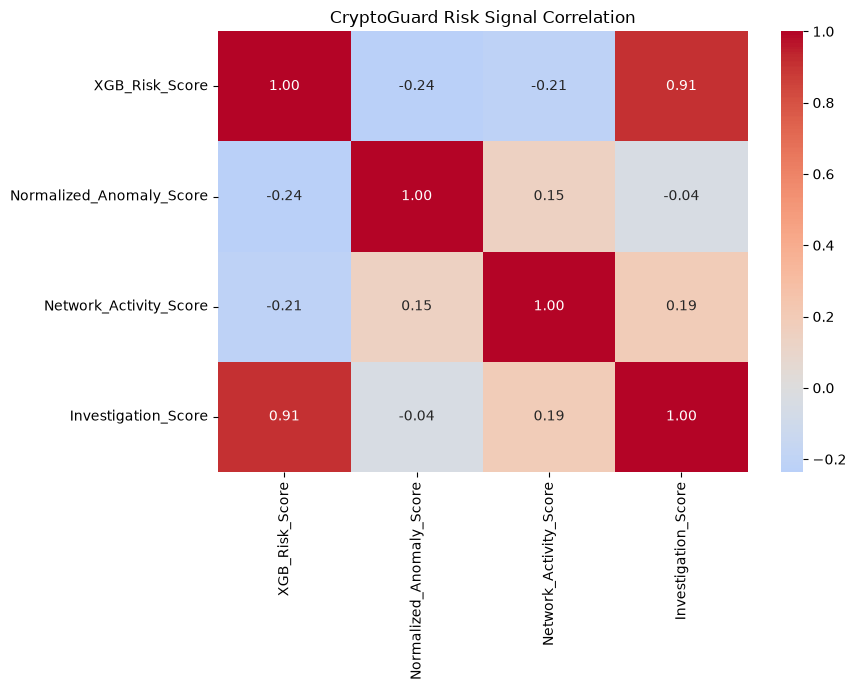

In [76]:
# Visualize relationships between CryptoGuard risk signals

plt.figure(figsize=(9, 7))

sns.heatmap(
    signal_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("CryptoGuard Risk Signal Correlation")
plt.tight_layout()
plt.show()

In [77]:
# ==========================================
# Step 6A - Highly Connected Transactions
# ==========================================

top_connected = (
    risk_results[
        [
            "txId",
            "Total_Degree",
            "In_Degree",
            "Out_Degree",
            "XGB_Risk_Score",
            "Anomaly_Score",
            "Risk_Category",
            "Investigation_Score"
        ]
    ]
    .sort_values(
        by="Total_Degree",
        ascending=False
    )
    .head(20)
)

print("Top 20 highly connected transactions:")
display(top_connected)

Top 20 highly connected transactions:


,txId,Total_Degree,In_Degree,Out_Degree,XGB_Risk_Score,Anomaly_Score,Risk_Category,Investigation_Score
19135,225859042,212,212,0,0.000028,0.044680,Low Risk,0.326369
32,234890810,199,199,0,0.980755,-0.084540,High Risk,0.836837
13062,225711361,167,167,0,0.275546,-0.051215,Low Risk,0.433817
21433,121654821,156,154,2,0.000072,0.001358,Low Risk,0.300252
26671,355174807,143,142,1,0.000787,-0.063172,Low Risk,0.261745
56,230658142,134,134,0,0.947957,-0.081533,High Risk,0.818967
23741,70245040,134,133,1,0.006258,-0.038948,Low Risk,0.279641
30,339175100,127,127,0,0.985337,-0.086159,High Risk,0.838602
19158,102570,122,0,122,0.000056,0.044264,Low Risk,0.326124
23149,2268197,121,121,0,0.002206,-0.027301,Low Risk,0.284233


In [78]:
# ==========================================
# Step 6B - Network Connectivity vs ML Risk
# ==========================================

network_risk_correlation = risk_results[
    ["Total_Degree", "XGB_Risk_Score"]
].corr()

print("Correlation between network connectivity and XGBoost risk:")
display(network_risk_correlation.round(3))

Correlation between network connectivity and XGBoost risk:


,Total_Degree,XGB_Risk_Score
Total_Degree,1.000,-0.055
XGB_Risk_Score,-0.055,1.000


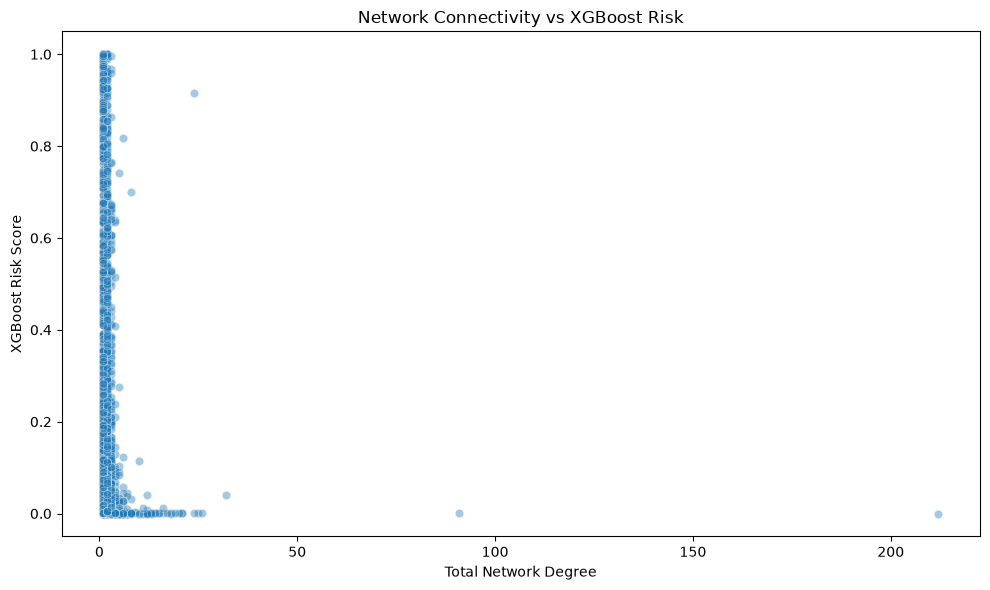

In [79]:
# Scatter plot: network connectivity vs XGBoost risk

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=risk_results.sample(
        n=min(5000, len(risk_results)),
        random_state=42
    ),
    x="Total_Degree",
    y="XGB_Risk_Score",
    alpha=0.4
)

plt.title("Network Connectivity vs XGBoost Risk")
plt.xlabel("Total Network Degree")
plt.ylabel("XGBoost Risk Score")

plt.tight_layout()
plt.show()

In [80]:
# ==========================================
# Step 6B - Network Connectivity vs ML Risk
# Alternative: Binned Bar Chart
# ==========================================

# Create network connectivity groups
risk_results["Network_Degree_Bin"] = pd.cut(
    risk_results["Total_Degree"],
    bins=[0, 1, 2, 5, 10, 20, 50, 100, np.inf],
    labels=[
        "1",
        "2",
        "3-5",
        "6-10",
        "11-20",
        "21-50",
        "51-100",
        "101+"
    ],
    include_lowest=True
)

# Calculate average ML risk for each group
network_risk_summary = (
    risk_results
    .groupby("Network_Degree_Bin", observed=False)
    .agg(
        Transaction_Count=("txId", "count"),
        Average_XGB_Risk=("XGB_Risk_Score", "mean")
    )
    .reset_index()
)

print("Network connectivity vs average XGBoost risk:")
display(network_risk_summary)

Network connectivity vs average XGBoost risk:


,Network_Degree_Bin,Transaction_Count,Average_XGB_Risk
0,1,51800,0.192035
1,2,74500,0.094228
2,3-5,27843,0.063791
3,6-10,1883,0.046756
4,11-20,861,0.056038
5,21-50,253,0.174072
6,51-100,52,0.399444
7,101+,13,0.343700


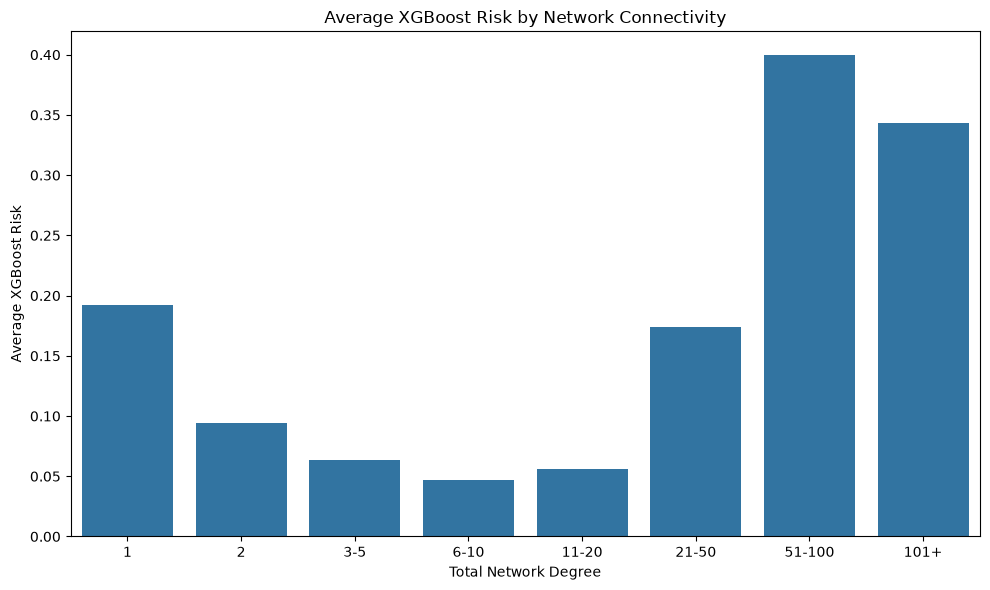

In [81]:
# Bar chart: Average XGBoost risk by network connectivity

plt.figure(figsize=(10, 6))

sns.barplot(
    data=network_risk_summary,
    x="Network_Degree_Bin",
    y="Average_XGB_Risk"
)

plt.title("Average XGBoost Risk by Network Connectivity")
plt.xlabel("Total Network Degree")
plt.ylabel("Average XGBoost Risk")

plt.tight_layout()
plt.show()

In [82]:
# ==========================================
# Step 6C - Network Risk Investigation Table
# ==========================================

investigation_table = risk_results[
    [
        "txId",
        "XGB_Risk_Score",
        "Anomaly_Score",
        "Anomaly_Flag",
        "Network_Activity_Score",
        "In_Degree",
        "Out_Degree",
        "Total_Degree",
        "Combined_Risk_Score",
        "Risk_Category",
        "Investigation_Score"
    ]
].copy()

# Sort by investigation priority
investigation_table = investigation_table.sort_values(
    by="Investigation_Score",
    ascending=False
).reset_index(drop=True)

print("CryptoGuard investigation table created!")
print("-----------------------------------------")
print("Rows:", len(investigation_table))
print("Columns:", len(investigation_table.columns))

print("\nTop 10 investigation-priority transactions:")
display(investigation_table.head(10))

CryptoGuard investigation table created!
-----------------------------------------
Rows: 157205
Columns: 11

Top 10 investigation-priority transactions:


,txId,XGB_Risk_Score,Anomaly_Score,Anomaly_Flag,Network_Activity_Score,In_Degree,Out_Degree,Total_Degree,Combined_Risk_Score,Risk_Category,Investigation_Score
0,30157957,0.996910,-0.027111,0,0.999472,43,0,43,0.822390,High Risk,0.881076
1,31168505,0.988690,-0.021163,0,0.999870,83,0,83,0.822020,High Risk,0.879813
2,66665998,0.993992,-0.027479,0,0.999656,58,0,58,0.820015,High Risk,0.879140
3,100832039,0.994929,-0.036303,0,0.999835,77,0,77,0.812684,High Risk,0.874414
4,197480855,0.994542,-0.044764,0,0.999618,54,0,54,0.804756,High Risk,0.869033
5,288315659,0.995744,-0.046867,0,0.999736,65,0,65,0.803694,High Risk,0.868509
6,66666000,0.992715,-0.044878,0,0.998760,25,0,25,0.803375,High Risk,0.867697
7,31168341,0.987862,-0.052401,0,0.999472,43,0,43,0.793168,High Risk,0.860388
8,37341170,0.995689,-0.068477,0,0.999348,39,0,39,0.784098,High Risk,0.855360
9,382997214,0.989094,-0.062430,0,0.999930,109,0,109,0.784954,High Risk,0.855168


In [83]:
# ==========================================
# Step 7 - Investigation Priority Categories
# ==========================================

medium_investigation_threshold = np.percentile(
    risk_results["Investigation_Score"],
    95
)

high_investigation_threshold = np.percentile(
    risk_results["Investigation_Score"],
    99
)

risk_results["Investigation_Priority"] = np.select(
    [
        risk_results["Investigation_Score"] >= high_investigation_threshold,
        risk_results["Investigation_Score"] >= medium_investigation_threshold
    ],
    [
        "High Priority",
        "Medium Priority"
    ],
    default="Low Priority"
)

priority_summary = (
    risk_results["Investigation_Priority"]
    .value_counts()
    .reindex(
        ["Low Priority", "Medium Priority", "High Priority"]
    )
    .reset_index()
)

priority_summary.columns = [
    "Investigation_Priority",
    "Transaction_Count"
]

priority_summary["Percentage"] = (
    priority_summary["Transaction_Count"]
    / len(risk_results)
    * 100
)

print("Investigation priority categories created!")
print("------------------------------------------")

print("Medium Priority threshold:",
      round(medium_investigation_threshold, 6))

print("High Priority threshold:",
      round(high_investigation_threshold, 6))

print("\nInvestigation Priority Distribution:")

display(priority_summary)

Investigation priority categories created!
------------------------------------------
Medium Priority threshold: 0.55445
High Priority threshold: 0.684103

Investigation Priority Distribution:


,Investigation_Priority,Transaction_Count,Percentage
0,Low Priority,149344,94.999523
1,Medium Priority,6288,3.999873
2,High Priority,1573,1.000604


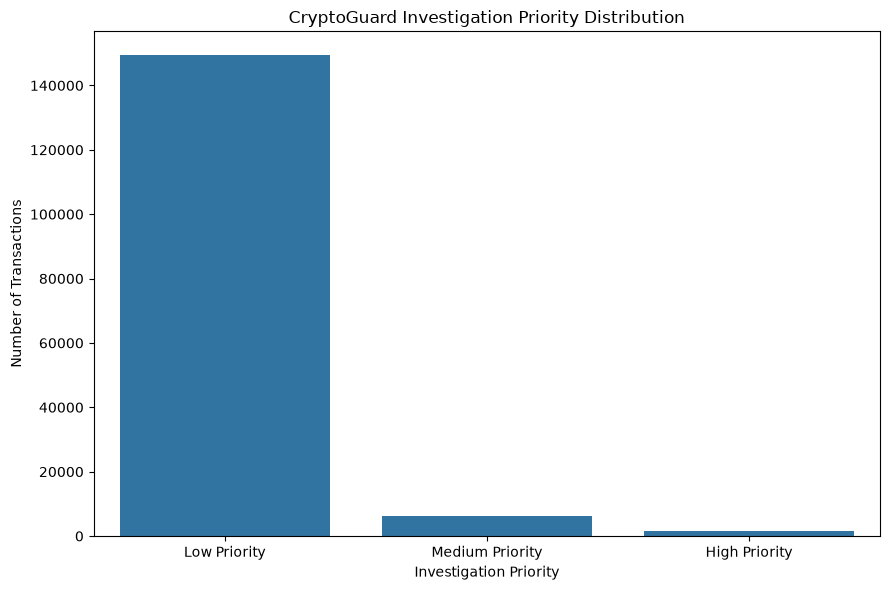

In [84]:
# Investigation Priority Distribution

plt.figure(figsize=(9, 6))

sns.barplot(
    data=priority_summary,
    x="Investigation_Priority",
    y="Transaction_Count"
)

plt.title("CryptoGuard Investigation Priority Distribution")
plt.xlabel("Investigation Priority")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [85]:
# ==========================================
# Step 8 - Save Final CryptoGuard Risk Dataset
# ==========================================

import os

output_path = "../Data/processed/cryptoguard_risk_results.csv"

risk_results.to_csv(
    output_path,
    index=False
)

print("CryptoGuard risk dataset saved successfully!")
print("---------------------------------------------")
print("File:", output_path)
print("Rows:", len(risk_results))
print("Columns:", len(risk_results.columns))
print("File exists:", os.path.exists(output_path))

CryptoGuard risk dataset saved successfully!
---------------------------------------------
File: ../Data/processed/cryptoguard_risk_results.csv
Rows: 157205
Columns: 14
File exists: True


In [86]:
# Verify saved dataset

saved_risk_results = pd.read_csv(
    "../Data/processed/cryptoguard_risk_results.csv"
)

print("Saved dataset verified!")
print("-----------------------")
print("Shape:", saved_risk_results.shape)

print("\nColumns:")
print(saved_risk_results.columns.tolist())

print("\nFirst 5 rows:")
display(saved_risk_results.head())

Saved dataset verified!
-----------------------
Shape: (157205, 14)

Columns:
['txId', 'XGB_Risk_Score', 'Anomaly_Score', 'Anomaly_Flag', 'Normalized_Anomaly_Score', 'Combined_Risk_Score', 'Risk_Category', 'In_Degree', 'Out_Degree', 'Total_Degree', 'Network_Activity_Score', 'Investigation_Score', 'Network_Degree_Bin', 'Investigation_Priority']

First 5 rows:


C:\Users\deeks\AppData\Local\Temp\ipykernel_29920\2110019621.py:3: DtypeWarning: Columns (12: Network_Degree_Bin) have mixed types. Specify dtype option on import or set low_memory=False.
  saved_risk_results = pd.read_csv(


,txId,XGB_Risk_Score,Anomaly_Score,Anomaly_Flag,Normalized_Anomaly_Score,Combined_Risk_Score,Risk_Category,In_Degree,Out_Degree,Total_Degree,Network_Activity_Score,Investigation_Score,Network_Degree_Bin,Investigation_Priority
0,30157957,0.996910,-0.027111,0,0.415177,0.822390,High Risk,43,0,43,0.999472,0.881076,21-50,High Priority
1,31168505,0.988690,-0.021163,0,0.433123,0.822020,High Risk,83,0,83,0.999870,0.879813,51-100,High Priority
2,66665998,0.993992,-0.027479,0,0.414068,0.820015,High Risk,58,0,58,0.999656,0.879140,51-100,High Priority
3,100832039,0.994929,-0.036303,0,0.387446,0.812684,High Risk,77,0,77,0.999835,0.874414,51-100,High Priority
4,197480855,0.994542,-0.044764,0,0.361921,0.804756,High Risk,54,0,54,0.999618,0.869033,51-100,High Priority


In [87]:
# ==========================================
# Step 8A - Fix Network Degree Bin Data Type
# ==========================================

risk_results["Network_Degree_Bin"] = (
    risk_results["Network_Degree_Bin"]
    .astype(str)
)

# Save the corrected dataset
risk_results.to_csv(
    "../Data/processed/cryptoguard_risk_results.csv",
    index=False
)

print("Network degree bin data type fixed!")
print("-----------------------------------")
print(
    "Data type:",
    risk_results["Network_Degree_Bin"].dtype
)

print("\nNetwork degree bins:")
print(
    risk_results["Network_Degree_Bin"]
    .value_counts()
    .sort_index()
)

Network degree bin data type fixed!
-----------------------------------
Data type: str

Network degree bins:
Network_Degree_Bin
1         51800
101+         13
11-20       861
2         74500
21-50       253
3-5       27843
51-100       52
6-10       1883
Name: count, dtype: int64


In [88]:
# Verify corrected CSV

saved_risk_results = pd.read_csv(
    "../Data/processed/cryptoguard_risk_results.csv",
    low_memory=False
)

print("Corrected dataset loaded successfully!")
print("----------------------------------------")
print("Shape:", saved_risk_results.shape)
print(
    "Network_Degree_Bin type:",
    saved_risk_results["Network_Degree_Bin"].dtype
)

print("\nRemaining missing values:")
print(saved_risk_results.isnull().sum().sum())

Corrected dataset loaded successfully!
----------------------------------------
Shape: (157205, 14)
Network_Degree_Bin type: str

Remaining missing values:
0


In [89]:
# ==========================================
# Step 9B - Save CryptoGuard Models
# ==========================================

import joblib
import os

# Create models folder if it does not exist
os.makedirs("../models", exist_ok=True)

# Save Logistic Regression
joblib.dump(
    logistic_model,
    "../models/logistic_regression_model.pkl"
)

# Save StandardScaler
joblib.dump(
    scaler,
    "../models/standard_scaler.pkl"
)

# Save Random Forest
joblib.dump(
    random_forest_model,
    "../models/random_forest_model.pkl"
)

# Save XGBoost
joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

# Save Isolation Forest
joblib.dump(
    isolation_forest,
    "../models/isolation_forest_model.pkl"
)

print("All CryptoGuard models saved successfully!")
print("-------------------------------------------")

for file_name in sorted(os.listdir("../models")):
    print("✓", file_name)

All CryptoGuard models saved successfully!
-------------------------------------------
✓ isolation_forest_model.pkl
✓ logistic_regression_model.pkl
✓ random_forest_model.pkl
✓ standard_scaler.pkl
✓ xgboost_model.pkl


In [90]:
# ==========================================
# Step 9C - Verify Saved CryptoGuard Models
# ==========================================

import joblib

# Load saved models
loaded_logistic = joblib.load("../models/logistic_regression_model.pkl")
loaded_scaler = joblib.load("../models/standard_scaler.pkl")
loaded_random_forest = joblib.load("../models/random_forest_model.pkl")
loaded_xgboost = joblib.load("../models/xgboost_model.pkl")
loaded_isolation_forest = joblib.load("../models/isolation_forest_model.pkl")

print("All saved models loaded successfully!")
print("--------------------------------------")

print("✓ Logistic Regression")
print("✓ StandardScaler")
print("✓ Random Forest")
print("✓ XGBoost")
print("✓ Isolation Forest")

All saved models loaded successfully!
--------------------------------------
✓ Logistic Regression
✓ StandardScaler
✓ Random Forest
✓ XGBoost
✓ Isolation Forest


In [91]:
# ==========================================
# Step 9D - Test Loaded XGBoost Model
# ==========================================

loaded_xgb_predictions = loaded_xgboost.predict(X_test)

loaded_xgb_probabilities = loaded_xgboost.predict_proba(X_test)[:, 1]

print("Loaded XGBoost model tested successfully!")
print("-------------------------------------------")
print("Predictions:", len(loaded_xgb_predictions))
print("Probabilities:", len(loaded_xgb_probabilities))

print("\nFirst 10 predictions:")
print(loaded_xgb_predictions[:10])

print("\nFirst 10 risk probabilities:")
print(loaded_xgb_probabilities[:10])

Loaded XGBoost model tested successfully!
-------------------------------------------
Predictions: 9973
Probabilities: 9973

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 risk probabilities:
[5.1329902e-05 2.1053790e-04 1.4437410e-01 5.4203130e-05 3.8924205e-05
 3.5706849e-05 5.6718400e-05 8.6008200e-05 4.3488286e-05 3.1490439e-05]
